# 5TF078 Deep Learning Course
## Laboration 3 om Tidsserier/RNN
Created by Tomas Nordström, Umeå University

In this exercise we will be looking at weather time-series analysis using RNN/LSTM in Keras


### Revisions:

*  2023-04-20 Initial version /ToNo
*  2023-05-01 Fixed a off-by-one bug in datasetgen, calculating offset. Also added timing of the model training. /ToNo
*  2023-09-14 Implemented a new datasetgen, that can handle targets with more than one time step (label_width>1) /ToNo
*  2023-10-22 Update keras imports to prepare for Keras 3.0 /ToNo
*  2023-11-30 Added calculation of target dataset size, and some minor text updates /ToNo
*  2023-12-02 Fixed a bug in datasetgen where last dataset might be too short. /ToNo
*  2024-04-22 Re-added lost "import sys". /Tomas
*  2024-11-29 Simplified the VG part. /Tomas
*  2024-12-04 The calculation of num_target_features was using the wrong value from target shape. /Tomas
* 2025-01-14 Clearified what is the output from a model.evaluate. /Tomas
* 2025-04-16 Clearified where student answers and kod is expected. /Tomas
* 2025-04-21 Added a note on loss and metrics. /Tomas
* 2025-04-27 Added AI-declaration. /Tomas
* 2025-04-29 Fixed bug in get_label_columns_indices how indices were calculated. /Tomas
* 2025-05-08 Fixed bug in datasetgen where I was off-by-one. /Tomas

# *AKINYI OCHOLLA*

# Introduktion

Laborationens mål är att använda ett återkopplat neuronnät (eng. Recurrent Neural Network, RNN) modell (t.ex. LSTM) för att göra prediktioner av en tidsserie av väderdata.

# Python Setup

In [140]:
# Import needed libraries
import tensorflow as tf
print('TensorFlow version:', tf.__version__)

import keras
print('Keras version:', keras.__version__)

# Matlab plotting
import matplotlib
import matplotlib.pyplot as plt
#mpl.rcParams['figure.figsize'] = (8, 6)
#mpl.rcParams['axes.grid'] = False

# Helper libraries
import os
import sys
import time
import datetime

import numpy as np
import pandas as pd
import sklearn
from   sklearn.model_selection import train_test_split

import IPython
import IPython.display
import seaborn as sns

TensorFlow version: 2.18.0
Keras version: 3.8.0


In [141]:
# Test for GPU and determine what GPU we have
import platform
import subprocess
gpu_devices = tf.config.list_physical_devices('GPU')

gpu_name = tf.test.gpu_device_name()
if gpu_name != '':
    print('TF-GPU-devname:',tf.test.gpu_device_name())
    sys_details = tf.sysconfig.get_build_info()
    physical_devices = tf.config.list_physical_devices('GPU')
    print("Num GPUs:", len(physical_devices))
    if platform.system() == "Darwin":
        print('GPU on Mac!')
    else:
        cuda_version = sys_details["cuda_version"]
        print('TF-cuda version:',cuda_version)
        if len(physical_devices)>0:
            process = subprocess.Popen(['nvidia-smi','-L'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
            print(process.communicate())
        # If possible to run code with 16 bits float instead of 32 bits float, this code activates such functionality:
        if gpu_devices:
            details = tf.config.experimental.get_device_details(gpu_devices[0])
            compute_capability=details.get('compute_capability')
            print("Compute capability:",compute_capability)
            if compute_capability[0]>6:
                print("Turning on mixed_float16")
                policy = keras.mixed_precision.Policy('mixed_float16')
                keras.mixed_precision.set_global_policy(policy)
else:
    print('TF-device CPU')

TF-GPU-devname: /device:GPU:0
Num GPUs: 1
TF-cuda version: 12.5.1
(b'GPU 0: Tesla P100-PCIE-16GB (UUID: GPU-607e1211-4f36-e391-b3b3-92e7cf5a66dd)\n', b'')
Compute capability: (6, 0)


I0000 00:00:1765230489.571475      47 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1765230489.572544      47 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# Del 1:  Första delen av uppgiften har följande underdelar
* Förstå dataförbehanlingen som görs nedan, dels att förbereda tidssekvensen med dess olika parametrar, dels förstå hur han skapar sekvenser/fönster som kan användas för att träna våra RNN-modeller.
* Reflekterar över vilken förlustfunktion som kan vara bäst för detta problem
* Skapa en baseline att jämföra med
* Träna en enkel LSTM modell för att prediktera en parameter (temperaturen) ett steg framåt m.h.a de senaste 24 värdena som input.

## Som data används väderdata

Denna laboration använder en <a href="https://www.bgc-jena.mpg.de/wetter/" class="external">vädertidsserie</a> uppmätt vid av Max Planck Institute for Biogeochemistry.

Denna datauppsättning innehåller 14 olika parametrar som lufttemperatur, atmosfärstryck och luftfuktighet. Dessa samlades in var tionde minut, med början 2003. För att vara lite effektiva kommer du endast att använda data som samlats in mellan 2009 och 2016. Den här delen av datamängden förbereddes av François Chollet för sin bok [Deep Learning with Python](https:// www.manning.com/books/deep-learning-with-python).


## Climate Data Time-Series
**Location**: Weather Station, Max Planck Institute for Biogeochemistry
in Jena, Germany

**Time-frame Considered**: Jan 10, 2009 - December 31, 2016

The table below shows the column names, their value formats, and their description.

Index| Features      |Format             |Description
-----|---------------|-------------------|-----------------------
1    |Date Time      |01.01.2009 00:10:00|Date-time reference
2    |p (mbar)       |996.52             |The pascal SI derived unit of pressure used to quantify internal pressure. Meteorological reports typically state atmospheric pressure in millibars.
3    |T (degC)       |-8.02              |Temperature in Celsius
4    |Tpot (K)       |265.4              |Temperature in Kelvin
5    |Tdew (degC)    |-8.9               |Temperature in Celsius relative to humidity. Dew Point is a measure of the absolute amount of water in the air, the DP is the temperature at which the air cannot hold all the moisture in it and water condenses.
6    |rh (%)         |93.3               |Relative Humidity is a measure of how saturated the air is with water vapor, the %RH determines the amount of water contained within collection objects.
7    |VPmax (mbar)   |3.33               |Saturation vapor pressure
8    |VPact (mbar)   |3.11               |Vapor pressure
9    |VPdef (mbar)   |0.22               |Vapor pressure deficit
10   |sh (g/kg)      |1.94               |Specific humidity
11   |H2OC (mmol/mol)|3.12               |Water vapor concentration
12   |rho (g/m ** 3) |1307.75            |Airtight
13   |wv (m/s)       |1.03               |Wind speed
14   |max. wv (m/s)  |1.75               |Maximum wind speed
15   |wd (deg)       |152.3              |Wind direction in degrees

In [3]:
from zipfile import ZipFile
zip_path = keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    # fname='jena_climate_2009_2016.csv.zip',
    # extract=True
    )
base_path, _ = os.path.split(zip_path)
ZipFile(zip_path).extractall(base_path)
csv_path, _ = os.path.splitext(zip_path)

df = pd.read_csv(csv_path)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
# My understanding of seeing true values of the data
print(df['T (degC)'][:2])

0   -8.02
1   -8.41
Name: T (degC), dtype: float64


In [5]:
# This lab will just deal with hourly predictions, so start by sub-sampling the data from 10 minute intervals to 1h:
df = df[5::6] # starting from index 5 take every 6th record.

date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')

In [6]:
print(df.shape)
# Let's take a glance at the data. Here are the first few rows:
df.head()

(70091, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
5,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
11,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
17,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
23,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
29,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


Here is the evolution of a few features over time.

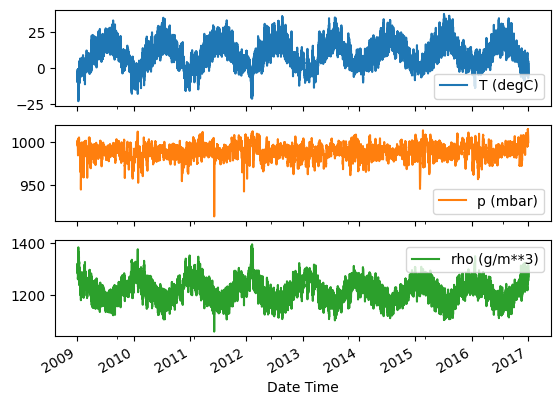

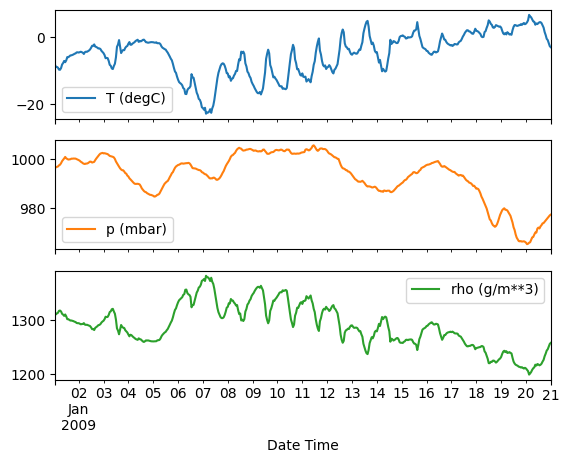

In [7]:
plot_cols = ['T (degC)', 'p (mbar)', 'rho (g/m**3)']
plot_features = df[plot_cols]
plot_features.index = date_time
_ = plot_features.plot(subplots=True)

plot_features = df[plot_cols][:480]
plot_features.index = date_time[:480]
_ = plot_features.plot(subplots=True)

### Inspect and cleanup

Next look at the statistics of the dataset:

In [8]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.212842,8.358886,913.60,984.20,989.57,994.720,1015.29
T (degC),70091.0,9.450482,8.423384,-22.76,3.35,9.41,15.480,37.28
Tpot (K),70091.0,283.493086,8.504424,250.85,277.44,283.46,289.530,311.21
Tdew (degC),70091.0,4.956471,6.730081,-24.80,0.24,5.21,10.080,23.06
rh (%),70091.0,76.009788,16.474920,13.88,65.21,79.30,89.400,100.00
VPmax (mbar),70091.0,13.576576,7.739883,0.97,7.77,11.82,17.610,63.77
VPact (mbar),70091.0,9.533968,4.183658,0.81,6.22,8.86,12.360,28.25
VPdef (mbar),70091.0,4.042536,4.898549,0.00,0.87,2.19,5.300,46.01
sh (g/kg),70091.0,6.022560,2.655812,0.51,3.92,5.59,7.800,18.07
H2OC (mmol/mol),70091.0,9.640437,4.234862,0.81,6.29,8.96,12.490,28.74


#### Wind velocity

One thing that should stand out is the `min` value of the wind velocity, `wv (m/s)` and `max. wv (m/s)` columns. This `-9999` is likely erroneous. There's a separate wind direction column, so the velocity should be `>=0`. Replace it with zeros:


In [9]:
wv = df['wv (m/s)']
bad_wv = wv == -9999.0
wv[bad_wv] = 0.0

max_wv = df['max. wv (m/s)']
bad_max_wv = max_wv == -9999.0
max_wv[bad_max_wv] = 0.0

# The above inplace edits are reflected in the DataFrame
df['wv (m/s)'].min()

0.0

### Feature engineering

Before diving in to build a model it's important to understand your data, and be sure that you're passing the model appropriately formatted data.

#### Wind
The last column of the data, `wd (deg)`, gives the wind direction in units of degrees. Angles do not make good model inputs, 360° and 0° should be close to each other, and wrap around smoothly. Direction shouldn't matter if the wind is not blowing.

Right now the distribution of wind data looks like this:

Text(0, 0.5, 'Wind Velocity [m/s]')

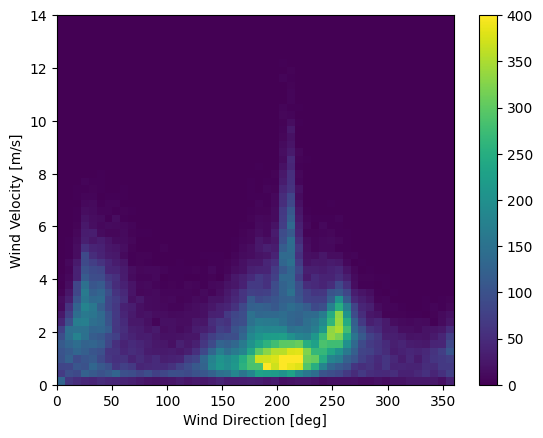

In [10]:
plt.hist2d(df['wd (deg)'], df['wv (m/s)'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')

But this will be easier for the model to interpret if you convert the wind direction and velocity columns to a wind **vector**:

In [11]:
wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')

# Convert to radians.
wd_rad = df.pop('wd (deg)')*np.pi / 180

# Calculate the wind x and y components.
df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)

# Calculate the max wind x and y components.
df['max Wx'] = max_wv*np.cos(wd_rad)
df['max Wy'] = max_wv*np.sin(wd_rad)

The distribution of wind vectors is much simpler for the model to correctly interpret.

(-11.305513973134667, 8.24469928549079, -8.27438540335515, 7.7338312955467785)

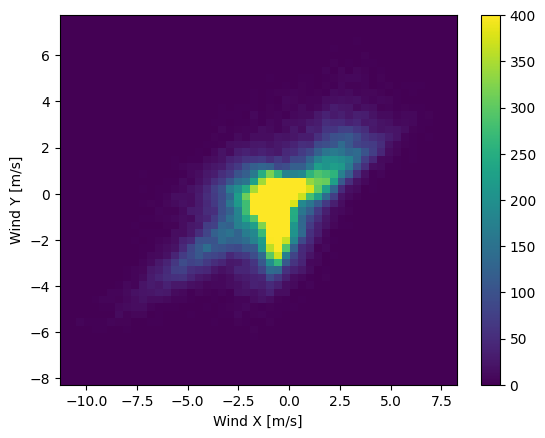

In [12]:
plt.hist2d(df['Wx'], df['Wy'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

#### Time

Similarly the `Date Time` column is very useful, but not in this string form. Start by converting it to seconds:

In [13]:
timestamp_s = date_time.map(datetime.datetime.timestamp)

Similar to the wind direction the time in seconds is not a useful model input. Being weather data it has clear daily and yearly periodicity. There are many ways you could deal with periodicity.

A simple approach to convert it to a usable signal is to use `sin` and `cos` to convert the time to clear "Time of day" and "Time of year" signals:

In [14]:
day = 24*60*60
year = (365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

Text(0.5, 1.0, 'Time of day signal')

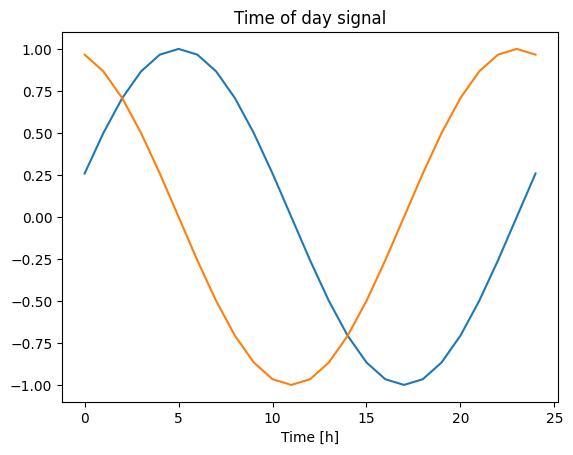

In [15]:
plt.plot(np.array(df['Day sin'])[:25])
plt.plot(np.array(df['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

This gives the model access to the most important frequency features. In this case you knew ahead of time which frequencies were important.

If you didn't know, you can determine which frequencies are important using an `fft`. To check our assumptions, here is the `tf.signal.rfft` of the temperature over time. Note the obvious peaks at frequencies near `1/year` and `1/day`:

In [16]:
# My own understanding
print(df['T (degC)'])

5        -8.05
11       -8.88
17       -8.81
23       -9.05
29       -9.63
          ... 
420521   -0.98
420527   -1.40
420533   -2.75
420539   -2.89
420545   -3.93
Name: T (degC), Length: 70091, dtype: float64


I0000 00:00:1765227239.674862      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


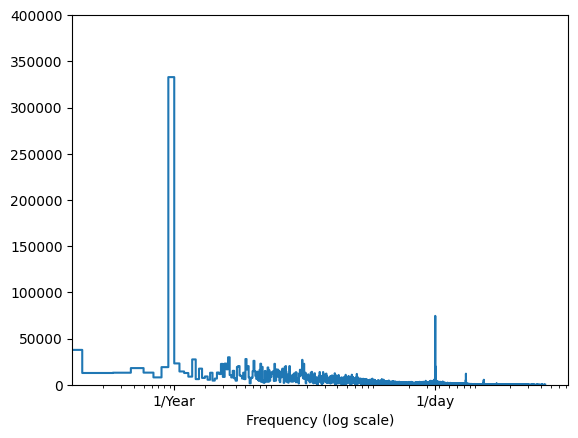

In [17]:
fft = tf.signal.rfft(df['T (degC)'])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df['T (degC)'])
hours_per_year = 24*365.2524
years_per_dataset = n_samples_h/(hours_per_year)

f_per_year = f_per_dataset/years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.ylim(0, 400000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 365.2524], labels=['1/Year', '1/day'])
_ = plt.xlabel('Frequency (log scale)')

## Uppgift Besvara följande frågor
Denna kod gör ganska omfattande förbehandling av väderdatat innan man kan använda det för träning, se till att du förstår vad som sker (men du behöver inte förändra något) och beskriv följade:
* Det finns en eller flera variabler med extrema (fysiskt omöjliga) värden, vilka är det, och vad görs för att hantera dem?
* Varför har maskininlärningsmodeller svårt att hantera en vindriktning som anges i grader, vad föreslås som alternativ att representera vindriktning istället?
* Även tid, mätt i sekunder/timmar etc. gör det onödigt svårt för modeller att hitta mönster i vissa typer av tidsserier, vad för slags variabler föreslås i koden att man lägger till för väderdata? Om detta istället hade varit energiförbrukningsdata, vilken periodisitet borde man då utökat med?


### STUDENTSVAR (FRÅGOR):
*   Min wind velocity (max_wv) och max wind velocity (wv) hade värden -9999 (omöjliga) och tillgavs istället 0. Wind velocity i m/s omvandlas till en vector wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')
*   Wind direction har värden 0 och 360 degrees vilket innebär att de är samma sak (men det förstår ju inte modellen) och att vinden är i samma riktning (norr). Eftersom degrees är en circulär mätning (den går aldrig över 360 eller under 0 degrees) är de svåra att använda i modellering, och omvandlades till vector (negativ och positiv mätning) genom att omvandla till radians - wd_rad = df.pop('wd (deg)')*np.pi / 180 och multiplicerar deras cosine och sine värden med wind velocity vectorn. Dessa komponenter av wind velocity och intensitet visualiseras. Vi ser en gul fläck vid nästan Wx=0 och Wy=0 m/s som jag tolkar att vinden är väldigt mild vid minus m/s (motsatta riktningen - Sydväst?). När jag tittar på den första visualiseringen så verkar det som att vinden blåser sydost-sydväst men är väldigt mild. Och det ser jag också i datan mellan 125,3 degrees och 360 degrees.
*   Tid anges i format 01.01.2009 00:10:00 i sekunder. Men detta har modeller svårt att se mönster i. För att se de periodiska dagliga/årliga mönster så omvandlas sekunder till time-of-day och time-of-year signaler cosine som kan ses i form av vågar och skrivs ut i en 24 timmars period per dag och 365 dagars period per år. Nu kan en RNN till exempel se mönstret och gradient descent i kurvorna.

##Datauppdelning och fönster

Förutom att dela upp denna tidsserie i våra tre olika datamängder behöver vi konvertera tidsserien till kortare sekvenser/fönster och lämpliga utvärden (motsvarande de "labels" vi använde i Lab 1&2).

Detta med fönster kan vara lite svårt att få ordning på så jag har skapat en lite introduktion här: https://colab.research.google.com/drive/1GU3WWJ4c3KWa8xrj5bZdnJp5PaIDjWYr?usp=sharing

## Back to our real data, start by finding splitting points

In [18]:
# Find index to where we want to split our data into our datasets
DataSplitRatios=(0.7,0.2,0.1) # Maybe one should check this sums up to 1?
n = len(df)
split1ix = int(n*DataSplitRatios[0])
split2ix = int(n*(DataSplitRatios[0]+DataSplitRatios[1]))
print(split1ix,split2ix,n)

49063 63081 70091


### Normalize the data

It is important to scale features before training a neural network. Normalization is a common way of doing this scaling. Subtract the mean and divide by the standard deviation of each feature.
Note that the mean and standard deviation should only be computed using the training data so that the models have no access to the values in the validation and test sets.

The data is normalized so that the data is in the same distribution which makes the models to be able to learn easier.

In [19]:
train_mean = df[0:split1ix].mean()
train_std = df[0:split1ix].std()
dfnorm = (df - train_mean) / train_std # this is the normalised training data set

In [20]:
# For my understanding of the normalization of the data. Why do we get the same 
print(dfnorm)  # This is the dfnorm for the whole dataset or the training set???

        p (mbar)  T (degC)  Tpot (K)  Tdew (degC)    rh (%)  VPmax (mbar)  \
5       0.945308 -1.982473 -2.041888    -1.918973  1.117102     -1.302851   
11      0.959770 -2.078372 -2.138166    -2.060964  1.044617     -1.330143   
17      0.986284 -2.070284 -2.132435    -2.045187  1.062738     -1.328843   
23      1.004362 -2.098014 -2.161090    -2.096820  1.008375     -1.336641   
29      1.061006 -2.165028 -2.232152    -2.187178  0.984214     -1.353535   
...          ...       ...       ...          ...       ...           ...   
420521  1.629854 -1.165600 -1.281981    -1.428459 -0.235937     -0.996148   
420527  1.535849 -1.214127 -1.322097    -1.640728 -0.580840     -1.019541   
420533  1.510540 -1.370107 -1.475683    -1.649333 -0.181573     -1.087119   
420539  1.445460 -1.386283 -1.487144    -1.685190 -0.217815     -1.094917   
420545  1.380380 -1.506445 -1.600615    -1.820009 -0.199694     -1.143002   

        VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  rho (g/m**3

In [21]:
# For my understanding of the normalisation of the data. 
# Why do we only normalise the training set above and use the dfnorm further below in the generator function???
val_mean = df[split1ix:split2ix].mean()
val_std = df[split1ix:split2ix].std()
dfnorm_val = (df - val_mean) / val_std # this is the normalised validation data set

In [22]:
print(dfnorm_val)

        p (mbar)  T (degC)  Tpot (K)  Tdew (degC)    rh (%)  VPmax (mbar)  \
5       0.738060 -2.287501 -2.332716    -2.317905  1.085169     -1.328012   
11      0.751960 -2.396012 -2.441366    -2.481915  1.009787     -1.355878   
17      0.777445 -2.386860 -2.434899    -2.463692  1.028633     -1.354551   
23      0.794821 -2.418237 -2.467236    -2.523332  0.972096     -1.362513   
29      0.849265 -2.494064 -2.547430    -2.627703  0.946969     -1.379764   
...          ...       ...       ...          ...       ...           ...   
420521  1.396024 -1.363198 -1.475156    -1.751322 -0.321956     -1.014850   
420527  1.305669 -1.418107 -1.520426    -1.996510 -0.680648     -1.038735   
420533  1.281343 -1.594600 -1.693749    -2.006450 -0.265420     -1.107737   
420539  1.218790 -1.612903 -1.706684    -2.047867 -0.303111     -1.115699   
420545  1.156238 -1.748869 -1.834736    -2.203594 -0.284266     -1.164796   

        VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  rho (g/m**3

Now peek at the distribution of the features. Some features do have long tails, but there are no obvious errors like the `-9999` wind velocity value.

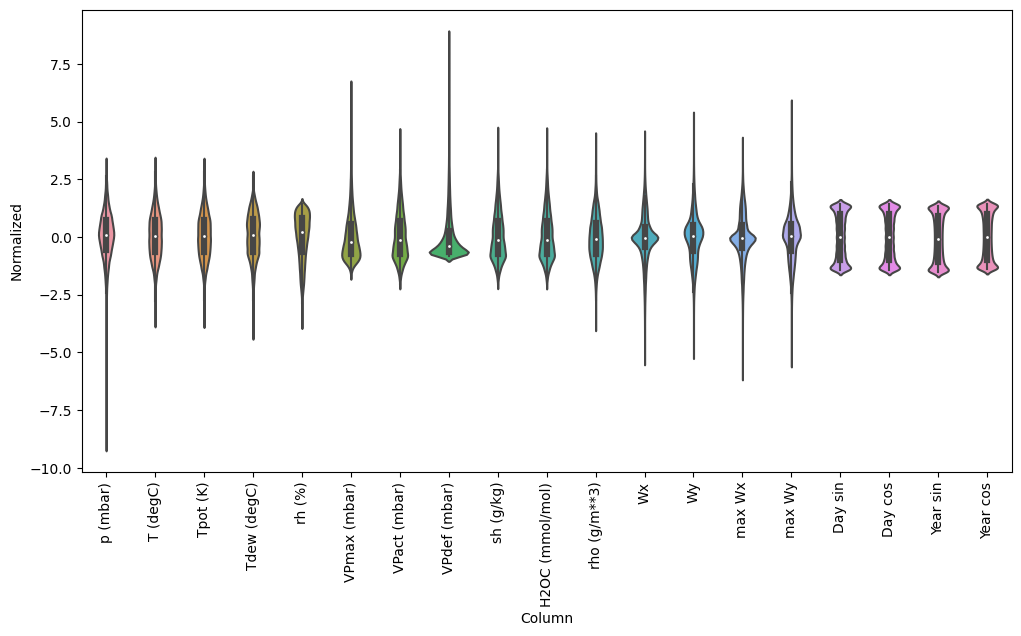

In [23]:
df_std = dfnorm.melt(var_name='Column', value_name='Normalized') # this is the normalised training data set, right???
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(df.keys(), rotation=90)

## Uppgift Del 1
Vi ska prediktera en parameter (temperaturen) ett steg framåt m.h.a de senaste 24 värdena som input.

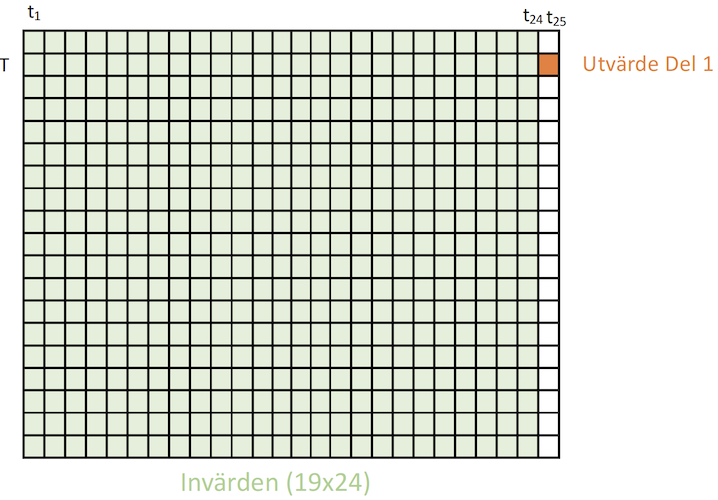

## Förbered våra tre "dataset"

In [24]:
def get_label_columns_indices(dataframe, label_columns=None):
    """
    Returns a dictionary mapping column names to their indices in the given DataFrame.
    Parameters:
        dataframe : pandas.DataFrame
            The DataFrame from which to extract column indices.
        label_columns : list of str, optional
            A list of column names to retrieve indices for. If None, all columns will be included.
    Returns:
        A dictionary where keys are column names and values are their corresponding indices.
    """
    if label_columns is None:
        # Return indices for all columns
        label_columns_indices = {name: i for i, name in enumerate(dataframe.columns)}
    else:
        # Return indices only for the specified label columns
        label_columns_indices = {name: dataframe.columns.get_loc(name) for name in label_columns}
    return label_columns_indices

In [25]:
# Test get_label_columns_indices
lcol= None
lci = get_label_columns_indices(dfnorm,lcol)
print(lci)
lcol= lcol= ['T (degC)']
lci = get_label_columns_indices(dfnorm,lcol)
print(lci)

{'p (mbar)': 0, 'T (degC)': 1, 'Tpot (K)': 2, 'Tdew (degC)': 3, 'rh (%)': 4, 'VPmax (mbar)': 5, 'VPact (mbar)': 6, 'VPdef (mbar)': 7, 'sh (g/kg)': 8, 'H2OC (mmol/mol)': 9, 'rho (g/m**3)': 10, 'Wx': 11, 'Wy': 12, 'max Wx': 13, 'max Wy': 14, 'Day sin': 15, 'Day cos': 16, 'Year sin': 17, 'Year cos': 18}
{'T (degC)': 1}


In [26]:
# Define a windowing function that converts a dataframe into a TF dataset
# Had to jump to some hoops for this as keras.utils.timeseries_dataset_from_array do not support label_width>1
# https://github.com/keras-team/tf-keras/issues/7
def datasetgen(dataframe, input_width=24, label_width=1, shift=1, batch_size=128,
  label_columns=None, start_index=None, end_index=None, shuffle=False):
  """
  Generate timeseries dataset from the given dataframe containing a data sequence.

  Parameters:
  - dataframe: The source time sequence dataframe.
  - input_width: Number of time steps in each input sequence.
  - label_width: Number of time steps in each label sequence.
  - shift: How many steps to shift the end of the input to get the label.
  - batch_size: Size of batches to generate.
  - label_columns: List of column names to extract as labels. If None, all columns are used.
  - start_index: Start index from the dataframe to consider data. Default is the start of the dataframe.
  - end_index: End index from the dataframe to consider data. Default is the end of the dataframe.
  - shuffle: Whether to shuffle the generated batches. Note: shuffling won't work in the current implementation.

  Returns:
  - A TensorFlow Dataset containing input and label sequences.
  """

  # If end index or start index is not given, assign them to the end or start of the dataframe respectively.
  if end_index is None:
      end_index = len(dataframe) + input_width - 1
  if start_index is None:
      start_index = 0

  # Generate a input timeseries dataset from the dataframe using keras.utils.timeseries_dataset_from_array
  input_ds = keras.utils.timeseries_dataset_from_array(
                  dataframe, targets=None, sequence_length=input_width,
                  sequence_stride=1, sampling_rate=1, batch_size=batch_size, shuffle=shuffle,
                  start_index=start_index, end_index=(end_index-(input_width+shift)))

  # Fetch the indices of the label columns from the dataframe.
  label_columns_indices = get_label_columns_indices(dataframe,label_columns) # get the selected columns
  targetsdf = dataframe[list(label_columns_indices)] # Note that we only use names and not the indices

  # Generate a timeseries dataset of label sequences from the dataframe.
  # Here we assume that label_width should be less than or equal to shift.
  target_ds = keras.utils.timeseries_dataset_from_array(
                  targetsdf, targets=None, sequence_length=label_width,
                  sequence_stride=1, sampling_rate=1, batch_size=batch_size, shuffle=shuffle,
                  start_index=(start_index+(input_width+shift-label_width)),
                  end_index=end_index-input_width)

  # Combine input and target datasets to form a single dataset.
  train_ds = tf.data.Dataset.zip(input_ds,target_ds)

  return train_ds

In [27]:
# Now create the used datasets for part 1

input_width=24    # Input sequence length
shift=1           # How many steps to target
label_width=1     # Target sequence length
lcol=['T (degC)'] # Target parameter(s)
train_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=0, end_index=split1ix)
val_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=split1ix, end_index=split2ix)  # Is this correct? WE are using the dfnorm based on the training data instead of the dfnorm_validation ??
test_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=split2ix, end_index=None)

In [28]:
"""
# MY OWN UNDERSTANDING OF BATCH AND INPUTS AND TARGETS Establish Training targets (to show how to unroll dataset)
train_targets = None
for batch in train_ds:
  inputs, targets = batch
  if train_targets == None:
    train_targets = targets
  else:
   train_targets = tf.concat([train_targets,targets], axis=0)

# Print number of targets (i.e. windows in target dataset)
num_train_targets = train_targets.shape[0]
print(f'No of targets = {num_train_targets}')
# And number of features
num_target_features = targets.shape[-1]
print(f'No of features in target = {num_target_features}')
"""



"\n# MY OWN UNDERSTANDING OF BATCH AND INPUTS AND TARGETS Establish Training targets (to show how to unroll dataset)\ntrain_targets = None\nfor batch in train_ds:\n  inputs, targets = batch\n  if train_targets == None:\n    train_targets = targets\n  else:\n   train_targets = tf.concat([train_targets,targets], axis=0)\n\n# Print number of targets (i.e. windows in target dataset)\nnum_train_targets = train_targets.shape[0]\nprint(f'No of targets = {num_train_targets}')\n# And number of features\nnum_target_features = targets.shape[-1]\nprint(f'No of features in target = {num_target_features}')\n"

In [29]:
"""
# MY OWN UNDERSTANDING OF Get a batch and look at the shapes for one of the datasets Training
eval_ds = train_ds
for batch in eval_ds:
  inputs, targets = batch
  batchlen = len(inputs)
  # We here have a batch of seqlen sequences
  print("A Batch Input shape = {0}, Output shape = {1}".format(inputs.shape,targets.shape))
  break

print(f'No batches = {eval_ds.__len__()}')
"""



'\n# MY OWN UNDERSTANDING OF Get a batch and look at the shapes for one of the datasets Training\neval_ds = train_ds\nfor batch in eval_ds:\n  inputs, targets = batch\n  batchlen = len(inputs)\n  # We here have a batch of seqlen sequences\n  print("A Batch Input shape = {0}, Output shape = {1}".format(inputs.shape,targets.shape))\n  break\n\nprint(f\'No batches = {eval_ds.__len__()}\')\n'

In [30]:
"""
# MY OWN UNDERSTANDING OF BATCH AND INPUTS AND TARGETS Establish VAL targets (to show how to unroll dataset)
val_targets = None
for batch in val_ds:
  inputs, targets = batch
  if val_targets == None:
    val_targets = targets
  else:
   val_targets = tf.concat([val_targets,targets], axis=0)

# Print number of targets (i.e. windows in target dataset)
num_val_targets = val_targets.shape[0]
print(f'No of targets = {num_val_targets}')
# And number of features
num_target_features = targets.shape[-1]
print(f'No of features in target = {num_target_features}')
"""



"\n# MY OWN UNDERSTANDING OF BATCH AND INPUTS AND TARGETS Establish VAL targets (to show how to unroll dataset)\nval_targets = None\nfor batch in val_ds:\n  inputs, targets = batch\n  if val_targets == None:\n    val_targets = targets\n  else:\n   val_targets = tf.concat([val_targets,targets], axis=0)\n\n# Print number of targets (i.e. windows in target dataset)\nnum_val_targets = val_targets.shape[0]\nprint(f'No of targets = {num_val_targets}')\n# And number of features\nnum_target_features = targets.shape[-1]\nprint(f'No of features in target = {num_target_features}')\n"

In [31]:
"""
# MY OWN UNDERSTANDING OF Get a batch and look at the shapes for one of the datasets
eval_ds = val_ds
for batch in eval_ds:
  inputs, targets = batch
  batchlen = len(inputs)
  # We here have a batch of seqlen sequences
  print("A Batch Input shape = {0}, Output shape = {1}".format(inputs.shape,targets.shape))
  break

print(f'No batches = {eval_ds.__len__()}')
"""

'\n# MY OWN UNDERSTANDING OF Get a batch and look at the shapes for one of the datasets\neval_ds = val_ds\nfor batch in eval_ds:\n  inputs, targets = batch\n  batchlen = len(inputs)\n  # We here have a batch of seqlen sequences\n  print("A Batch Input shape = {0}, Output shape = {1}".format(inputs.shape,targets.shape))\n  break\n\nprint(f\'No batches = {eval_ds.__len__()}\')\n'

In [32]:
# Establish test targets (to show how to unroll dataset)
test_targets = None
for batch in test_ds:
  inputs, targets = batch
  if test_targets == None:
    test_targets = targets
  else:
   test_targets = tf.concat([test_targets,targets], axis=0)

# Print number of targets (i.e. windows in target dataset)
num_test_targets = test_targets.shape[0]
print(f'No of targets = {num_test_targets}')
# And number of features
num_target_features = targets.shape[-1]
print(f'No of features in target = {num_target_features}')


No of targets = 6985
No of features in target = 1


In [33]:
# Get a batch and look at the shapes for one of the datasets
eval_ds = test_ds
for batch in eval_ds:
  inputs, targets = batch
  batchlen = len(inputs)
  # We here have a batch of seqlen sequences
  print("A Batch Input shape = {0}, Output shape = {1}".format(inputs.shape,targets.shape))
  break

print(f'No batches = {eval_ds.__len__()}')

A Batch Input shape = (128, 24, 19), Output shape = (128, 1, 1)
No batches = 55


### Now we can use the datasets needed for training

## Uppgift:
Reflekterar över vilken förlustfunktion som kan vara bäst för detta problem (mean squared error, MSE, eller mean absolute error,  MAE, eller något annat?) och varför denna exempelkod väljer att  använda just “loss=tf.losses.MeanSquaredError()” och “metrics=tf.metrics.MeanAbsoluteError()”.  Tillägna en sektion i din rapport till att argumentera för skillnaden mellan en förlustfunktion (loss) och ett prestationsmått (metric), samt motivera ditt val av förlustfunktion.



### STUDENTSVAR (FRÅGOR):
*   På sidor 546-547 står det att de mest vanliga förlustfunktioner för tidserier och prognoser är MAE, MAPE, och MSE metrics. MAE (Mean absolute error) ger den absoluta skillnaden mellan prediction och riktiga värdena. Däremot ger MAPE (Mean absolute percentage error) den procentuella förlusten jämfört med det riktiga värdet. Och det kan avgöra hurvida en modell igentligen passar för att göra prognoser för en individuell data eller ej särskilt om de olika features i ett dataset som prediktionerna siktar mot skiljer sig mycket. MSE loss=tf.losses.MeanSquaredError() blir betydligt större för större fel i prediktioner. Den aksentuerar dem och visar på att en model gör större fel i prediktion. Den används mycket för regressionsmodeller. En förlustfunktion (loss) t.ex CategoricalCrossentropy() används för kategoriseringsfel. En loss används också t.ex i CNN i gradient descent för att reglera vikter och därmed förbättra modellen. Därför används olika activationfunctions.
*   I vårt fall här så vill vi prognostisera t.ex temperatur utifrån tidigare temperaturer samt andra relaterade data. Det är en regressionsmodell. Jag tänker att jämfört med prognoserna av antal resenärer av buss eller tåg i kapitell 15 i boken där väldigt exakta antal inte verkar behövas, så är väderelement betydligt viktigare om prognoserna skiljer sig mycket från de aktuella värdena. Modellen behöver vara så precis som möjligt. Därför är nog MSE det bästa metric att använda. 

You will train a lot of models, so it might be useful to package the training procedure into a function. But note that for Part 2 we probably need to use a modified metric, so when that happens you might want metrics as an extra parameter to this function.

In [34]:
MAX_EPOCHS = 30

def compile_and_fit(model, patience=5):
  early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min',
                                                    restore_best_weights = True)

  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=tf.optimizers.Adam(),
                metrics=[tf.metrics.MeanAbsoluteError()])

  start = time.time()
  history = model.fit(train_ds, epochs=MAX_EPOCHS,
                      validation_data=val_ds,
                      callbacks=[early_stopping])
  end = time.time()
  print(f'Time to run: {end - start:.1f}s')

  return history,model

### Note on loss and metrics
**Loss vs. Metrics:** Loss is used *during* training to guide weight updates. Metrics are used to *evaluate* performance, both during training (on validation data) and after training (on the test set).
* Both loss and metric are set up during `model.compile()`.
* During training, i.e `model.fit()` the loss function steers the weight update, while metrics are only there to inform us of how the training process is doing for our particular metric we are interested in. Both loss and metrics are logged after each epoch for both training and validation datasets.
* The when we run `model.evaluate()` we will get the loss and **all** the metrics defined as a return value.
 * Note that in previous exercises we used accuracy as a metric and wrote "`test_loss, test_acc = model.evaluate(test_images,to_categorical(test_labels))`" to get both loss and accuracy for the test dataset.
 * But now we will get loss and the metric(s) mae and/or mse as a return value!
 * Also note that if we have two metrics defined then `model.evaluate()` will return three values.

##Skapa en Modell

In [35]:
# Define a first simple LSTM model with 32 units
lstm_model_baseline = keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    keras.layers.LSTM(32, return_sequences=False),
    # Shape => [batch, time, features]
    keras.layers.Dense(units=num_target_features)
])

Compile and train this model, and then plot the training curves. That is, the following graph shows the baseline LSTM model with a 24 sized(timepoints) array as input and a 1 sized output prediction(next timepoint).

In [36]:
# Compile and train this model
history_lstm_baseline,lstm_model_baseline1=compile_and_fit(lstm_model_baseline)

Epoch 1/30


I0000 00:00:1765227248.619581     106 cuda_dnn.cc:529] Loaded cuDNN version 90300


383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.3333 - mean_absolute_error: 0.3760 - val_loss: 0.0249 - val_mean_absolute_error: 0.1244
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0288 - mean_absolute_error: 0.1258 - val_loss: 0.0180 - val_mean_absolute_error: 0.1048
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0177 - mean_absolute_error: 0.0999 - val_loss: 0.0135 - val_mean_absolute_error: 0.0888
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0128 - mean_absolute_error: 0.0844 - val_loss: 0.0130 - val_mean_absolute_error: 0.0872
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0113 - mean_absolute_error: 0.0790 - val_loss: 0.0105 - val_mean_absolute_error: 0.0774
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0096 - mean_absolute_error: 0.0724 - val_loss: 0.0094 - val_mean_absolute_error: 0.0728
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0088 - mean_absolute_error: 0.0690 - val_l

Test MSE: 0.0067
Test MAE: 0.0613


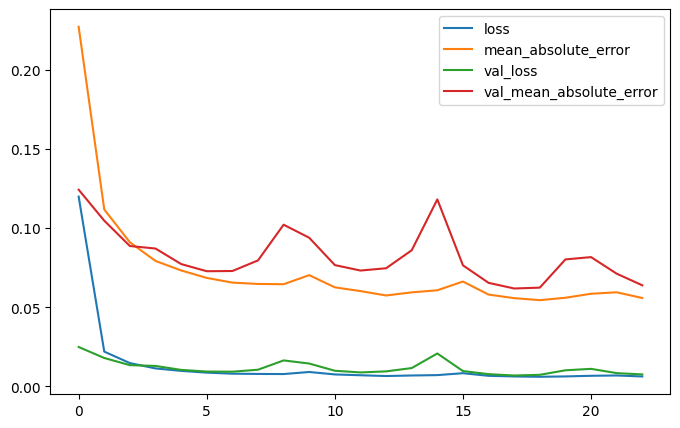

In [37]:
# Evaluate the model.
test_loss, test_metric_mae = lstm_model_baseline1.evaluate(test_ds, verbose=0)
print(f'Test MSE: {test_loss:.4f}')
print(f'Test MAE: {test_metric_mae:.4f}')


# Plot the training curves
pd.DataFrame(history_lstm_baseline.history).plot(figsize=(8,5))
plt.show()

Note that this is the normalised loss!

## Example plot of predictions

In [38]:
# define a plot function to show how well it is prediction
def show_plot(plot_data, delta, title):
    labels = ["History", "True Future", "Model Prediction"]
    marker = [".-", "rx", "go"]
    time_steps = list(range(-(plot_data[0].shape[0]), 0))
    if delta:
        future = delta
    else:
        future = 0

    plt.title(title)
    for i, val in enumerate(plot_data):
        if i:
            plt.plot(future, plot_data[i], marker[i], markersize=10, label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
    plt.legend()
    plt.xlim([time_steps[0], (future + 5) * 2])
    plt.xlabel("Time-Step")
    plt.show()
    return

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


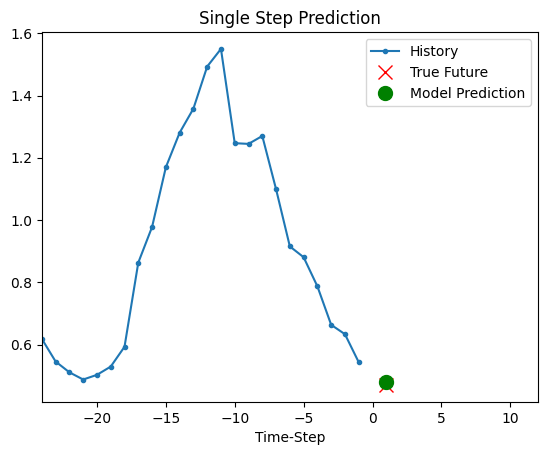

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


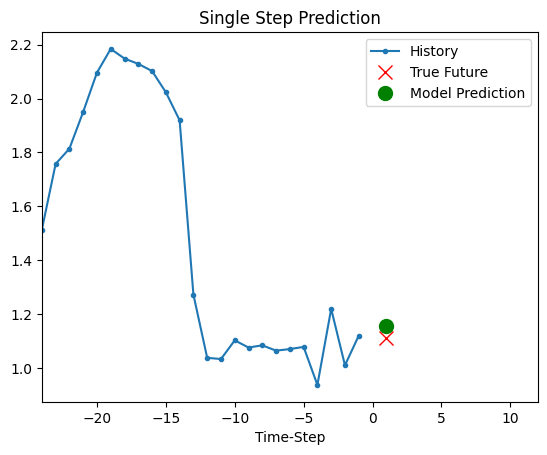

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


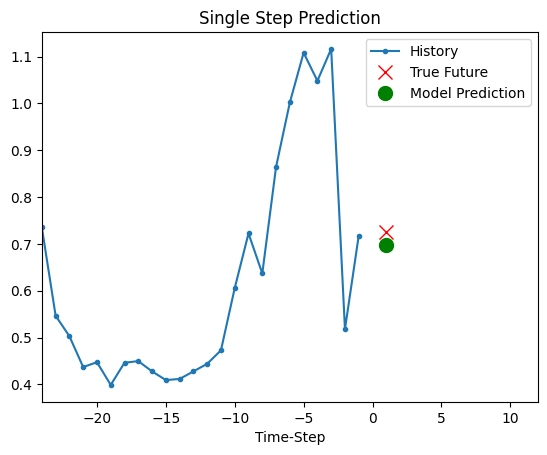

In [39]:
for x, y in val_ds.take(3):
    show_plot(
        [x[0][:, 1].numpy(), y[0].numpy(), lstm_model_baseline1.predict(x)[0]],
        1,
        "Single Step Prediction",
    )

## Plot Some Results - Unnormalised
Just for fun, some code to unnormalise the predictions, and plot the difference between the true values and the predictions. But for the lab you can work in normalised space as long as you are consistent!

In [40]:
predict = lstm_model_baseline1.predict(test_ds)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [41]:
def unnorm(data,label_columns_index):
  assert len(label_columns_index) == data.shape[-1]
  tm = train_mean.get(list(label_columns_index)).values
  ts = train_std.get(list(label_columns_index)).values
  return  data * ts + tm


In [42]:
ttt = unnorm(test_targets,label_columns_index=lci).numpy().squeeze()
ttp = unnorm(predict,label_columns_index=lci).squeeze()

In [110]:
# Temperature predicted and test_target unnormalised of 1st data in set
print(predict[0])
print(ttt[0])

[-1.0093503]
1.0199999999999996


In [44]:
# Temperature test_targets unnormalised the 25th in the dataset of test_targets
print(ttt[26])

-0.3800000000000008


In [45]:
# Temperature predicted unnormalised the 25th in the dataset of predicted values
print(ttp[26])

-0.7592255028518995


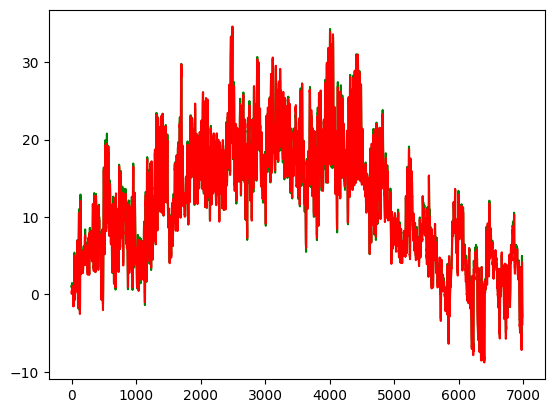

In [46]:
plt.figure()
plt.plot(ttt,color='g')
plt.plot(ttp, color='r')

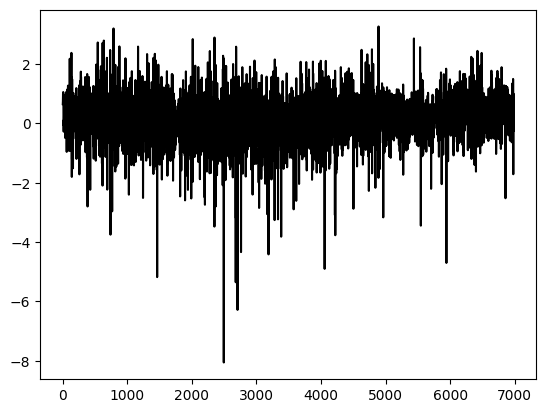

In [47]:
plt.figure()
plt.plot(ttt-ttp,color='k')


##Uppgift - baseline
För att ha något att jämföra med så skulle vi behöva räkna ut en "baseline". En vanlig och enkel baseline är att bara "prediktera" nästa värde att vara samma som nuvarande värde (detta är ganska rimligt för väderprediktion).

* Räkna ut en baseline med samma förlustfunktion som du bestämt dig för att använda i denna laboration.
* Var den enkla LSTM-modellen ovan bättre eller sämre än din baseline?

Tips: Du ska räkna ut MSE/MEA utifrån ditt testdata. Det finns två huvudmetoder att skapa de prediktiva värden och sanna värden vi behöver för detta.
1.   Plocka ut hela temperaturserien från dfnorm: "dfnorm['T (degC)'].to_numpy()" och sedan bestämma start och slutpunkter i denna tidsserie för input (notera att det är 24 invärden och därför är startpunkten förskjuten motsvarande och sedan för Del 2 så behöver man ta hänsyn till att vi vill ha utvärden 24 steg framåt.)
> *Om denna metods används, kolla att de två tidsserierna (prediction & target) har samma längd som räknades ut mha* **num_test_targets**!

2.   Det andra sättet är att loopa över alla batcher i testdataströmmen
```
for batch in eval_ds:
      inputs, targets = batch
```
och sedan extrahera rätt del av "inputs" (full batch, last input-sequece data, temp column) och hela "targets" för att sedan konkatenera alla batcher till en lång vektor.

### STUDENTSVAR (KOD):

In [48]:
print(num_test_targets) # number of test targets

6985


In [49]:
num_pred_targets = len(predict)
print(num_pred_targets) # number of test predictions

6985


In [112]:
temps_targets = dfnorm['T (degC)'].to_numpy()
print(temps_targets[25]) # the 24th temperature in the targets which correspond with the predicted temperature at step 1 after the 24th input_width


-1.548039756185141


In [52]:
print(predict[25]) # this is the LSTM predicted temperature at the step 1 after the 24 input_width

[-1.0903585]


In [53]:
# Jämförelse av LSTM1_prediction och test target
difference_in_temp = predict[25] - temps_targets[25]
print(difference_in_temp)

[0.4576813]


In [54]:
print(predict[0])

[-1.0093503]


### Jämförelse
Temp_targets på den 25e platsen i dfnorm var -1.548 degC medans det LSTM predikterade värdet var -1.07. De skiljer sig med 0.4777106 deg C.

In [55]:
temps_targets = dfnorm['T (degC)'].to_numpy()
print(temps_targets)

[-1.98247323 -2.07837211 -2.07028426 ... -1.3701069  -1.38628261
 -1.50644506]


In [56]:
# Baseline model predikterade 1 temperatur är samma som föregående temperatur

def baseline_temp_prediction(dfnorm,label_columns_index=lci):
    temps_targets = dfnorm['T (degC)'].to_numpy()
    if label_columns_index != 0:
        temp_baseline = temps_targets[label_columns_index-1]
    else:
        temp_baseline = temps_targets[label_columns_index]
    
    return temp_baseline

In [57]:
temp_predicted = baseline_temp_prediction(dfnorm, 25)
print(temp_predicted)

-1.5653708789620246


In [58]:
# Jämförelse av baseline_prediction och test target
difference_in_temp = temp_predicted - temps_targets[25]
print(difference_in_temp)

-0.017331122776883756


In [59]:
# Min Baseline model for all temperature targets in test data
def baseline_temps_predictions(dfnorm,label_columns_index=lci):
    temps_targets = dfnorm['T (degC)'].to_numpy()
    temps_preds_list = []
    loss_sum = 0
    for label_columns_index in range(num_test_targets):
        if label_columns_index != 0:
            temp_baseline = temps_targets[label_columns_index-1]
            temps_preds_list.append(temp_baseline)
            loss = temps_targets[label_columns_index] - temp_baseline
            loss_sum += loss
        else:
            temp_baseline = temps_targets[label_columns_index]
            temps_preds_list.append(temp_baseline)
            loss = temps_targets[label_columns_index] - temp_baseline
            loss_sum += loss
    # mse = 1/n*(sum(preds-targets)^2)
    mse = (loss_sum * loss_sum)/num_test_targets
    return temps_preds_list, mse

In [60]:
temps_preds_list,mse = baseline_temps_predictions(dfnorm)
print(f'Mean Squared error of baseline model: {mse}')
# print(temps_preds_list)


Mean Squared error of baseline model: 0.00020870701664831153


In [61]:
print(f'LSTM1 har mse = {test_loss}')

LSTM1 har mse = 0.006725650280714035


In [62]:
print(f'Predikterad temperatur med Baseline model: {temps_preds_list[25]}')  # Jämför predikterad temperatur med Baseline model och target
print(f'Riktiga temperaturen i test data set: {temps_targets[25]}')
print(f'Baseline Difference : {temps_preds_list[25] - temps_targets[25]} compared to LSTM1 Difference : {predict[25] - temps_targets[25]}' )

Predikterad temperatur med Baseline model: -1.5653708789620246
Riktiga temperaturen i test data set: -1.548039756185141
Baseline Difference : -0.017331122776883756 compared to LSTM1 Difference : [0.4576813]


### Jämförelse av MSE av Bseline-LSTM1 och Baseline_temps_predictions model
LSTM1 har mse = 0.006224046926945448, medans 
Min baseline model har mse = 0.00020870701664831153. 
Så Baseline modellen slår LSTM1 modellen

In [63]:
# Experimenting

"""
preds = predict
test_steps = (len(df) - split2ix - input_width)
test_gen = test_ds
samples = inputs
targets = targets

def evaluate_naive_method():
    batch_mses = []
    for step in range(test_steps):
        samples, targets = batch
        preds = samples[:, -1, 1]
        mse = (np.square(preds - targets)).mean(axis=1)
        batch_mses.append(mse)
    print(np.mean(batch_mses))
    
evaluate_naive_method()

"""


'\npreds = predict\ntest_steps = (len(df) - split2ix - input_width)\ntest_gen = test_ds\nsamples = inputs\ntargets = targets\n\ndef evaluate_naive_method():\n    batch_mses = []\n    for step in range(test_steps):\n        samples, targets = batch\n        preds = samples[:, -1, 1]\n        mse = (np.square(preds - targets)).mean(axis=1)\n        batch_mses.append(mse)\n    print(np.mean(batch_mses))\n    \nevaluate_naive_method()\n\n'

## Uppgift - En bättre LSTM-modell
Nästa steg är att hitta en förbättrad LSTM-modell för fallet när man vill prediktera en parameter (temperaturen) ett steg framåt m.h.a de senaste 24 värdena som input. Notera att det kan vara svårt att slå den första enkla LSTM-modellen för just detta problem och data, men försök.

Du kan pröva med fler noder i ditt lager eller lägga till fler lager. Notera att man INTE bör använda activation='relu' för LSTM-modeller då dessa modellerna inte kan köras på GPU:n i så fall. Om du lägger till flera lager så vill du nog ange "return_sequences=True" till alla lager utom det sista.

Pröva att använda någon av de de regulariseringsmetoder som finns tillgängliga för RNN och se ifall du på så sätt kan förbättra din modell (detta ska vara regularisering av LSTM lagren, inte t.ex. dropout mellan lagren). Argumentera för dina val av regularisering och diskutera dina resultat. Notera även ifall någon av regulariseringarna du testat tvingar modellen till CPU:n istället för GPU:n. Beskrivning av vilka parametrar som styr regulariseringen i LSTM finns här: https://keras.io/api/layers/recurrent_layers/lstm/
(kernel_regularizer, recurrent_regularizer, bias_regularizer, activity_regularizer, dropout, recurrent_dropout).
Notera att dessa regulariseringsmetoder sällan har get någon väsentlig förbättring i denna laboration, vad kan detta bero på?

Att vanlig dropout kanske inte är så bra finns först beskrivet i följande papper:
* Zaremba, W., Sutskever, I., & Vinyals, O. (2014). Recurrent neural network regularization. arXiv preprint arXiv:1409.2329

Men det kan ändå vara värt att pröva just innan de sista kompakta lagren i modellen?

**Analysera dina resultat och jämför de olika modellerna.**


### STUDENTSVAR (KOD):

In [64]:
# Better LSTM2 model(s): definition, compile and run, evaluate, and compare!
# Define a first simple LSTM model with 32 units
import tensorflow as tf
from tensorflow.keras import layers, regularizers
lstm_model_baseline2 = keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    keras.layers.LSTM(256, return_sequences=False), # Tried return_sequences False, True and LSTM(32, 128, 256)
    #keras.layers.LSTM(256, return_sequences=True), # Tried with  kernel_regularizer=regularizers.L2(0.05) ochkernel_regularizer=regularizers.L2(0.05) samt recurrent_regularizer.l2(0.01)
    # Tried with dropout
    # Added dropout rate Experimenting
    # keras.layers.Dropout(0.5),  # Experimenting with dropout rate
    # Shape => [batch, time, features]
    keras.layers.Dense(units=num_target_features)
])

In [65]:
MAX_EPOCHS = 30

def compile_and_fit(model, patience=5):
  early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min',
                                                    restore_best_weights = True)

  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=tf.optimizers.Adam(),
                metrics=[tf.metrics.MeanAbsoluteError()])

  start = time.time()
  history = model.fit(train_ds, epochs=MAX_EPOCHS,
                      validation_data=val_ds,
                      callbacks=[early_stopping])
  end = time.time()
  print(f'Time to run: {end - start:.1f}s')

  return history,model

In [66]:
# Compile and train this model
history_lstm_baseline,lstm_model_baseline2=compile_and_fit(lstm_model_baseline2)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.1447 - mean_absolute_error: 0.2223 - val_loss: 0.0321 - val_mean_absolute_error: 0.1462
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0178 - mean_absolute_error: 0.0960 - val_loss: 0.0116 - val_mean_absolute_error: 0.0818
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0105 - mean_absolute_error: 0.0765 - val_loss: 0.0190 - val_mean_absolute_error: 0.1118
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0100 - mean_absolute_error: 0.0735 - val_loss: 0.0126 - val_mean_absolute_error: 0.0873
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0082 - mean_absolute_error: 0.0661 - val_loss: 0.0109 - val_mean_absolute_error: 0.0805
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0080 - mean_absolute_error: 0.0649 - val_loss: 0.0084 - val_mean_absolute_error: 0.0691
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0075 - mean_absolute_error: 0.0

Test MSE: 0.0076
Test MAE: 0.0667


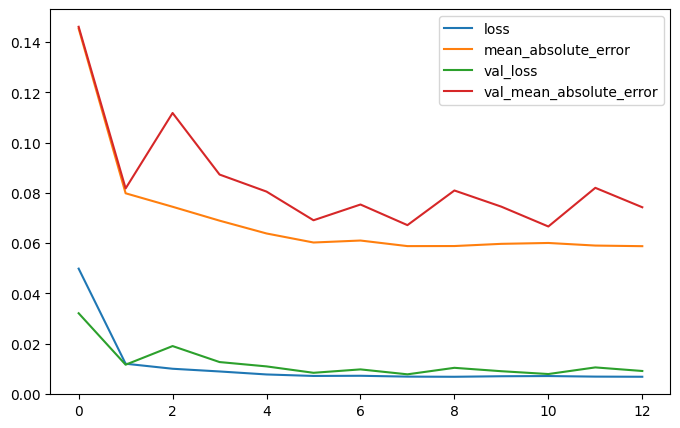

In [67]:
# Evaluate the model.
test_loss, test_metric_mae = lstm_model_baseline2.evaluate(test_ds, verbose=0)
print(f'Test MSE: {test_loss:.4f}')
print(f'Test MAE: {test_metric_mae:.4f}')


# Plot the training curves
pd.DataFrame(history_lstm_baseline.history).plot(figsize=(8,5))
plt.show()

### STUDENTSVAR (ANALYS):
Med LSTM(256) och return sequence False blev Test MSE: 0.0060, Test MAE: 0.0553 vilket slår det första LSTM som hade MSE: 0.0062 och MAE: 0.0572. 
Jag provade också att höja patience till 10 och epochs till 80 och fick då Test MSE: 0.0060 och MAE 0.0546. Men jag tror att modellen övertränar. När Jag har använde regularization kernel_regularizer=l2(0.05), och recurrent_regularizer=l2(0.05) så fick jag MSE 0.0356 och MAE 0.1183 så resultaten blev inte bättre. Med enbart recurrent_regularizer=l2(0.01) fick jag Test MSE: 0.0119, Test MAE: 0.0787. Jag tror inte att regularizers igentligen hjälper modelen att undvika att överträna i detta fall. Och utan regularizer men med dropout så fick jag Test MSE: 0.0064 och Test MAE: 0.0582. Så dessa har inte hjälpt mina resultat.

# Del 2:  Prediktera flera steg framåt
I del 2 ska du göra två olika modeller som båda ska prediktera vad temperaturen är 24 timmar framåt, baserat på de senaste 24 timmarnas mätvärden. D.v.s om din input-sekvens t.ex. löper från timme 1 till och med timme 24, så ska du prediktera vad temperaturen är vid timme 48.

## Uppgift 24-timmar framåt med "direkt prediktion"
Del 2.1. Direkt-prediktion av det värdet du söker (single-step with a new target time-step). D.v.s använd 24 timmars input-värden för att endast prediktera ett utvärde. 24 timmar framåt (timme 48).

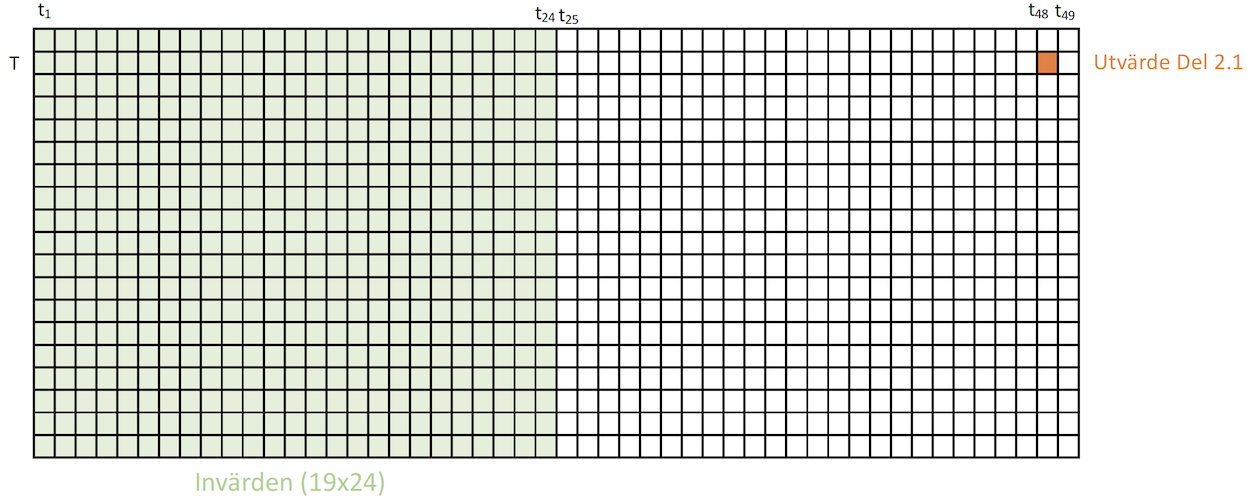

### STUDENTSVAR (KOD):

### LSTM3 med shift 24 i stället för 1

In [68]:
# LSTM3 med shift 24 i stället för 1
# Define a windowing function that converts a dataframe into a TF dataset
# Had to jump to some hoops for this as keras.utils.timeseries_dataset_from_array do not support label_width>1
# https://github.com/keras-team/tf-keras/issues/7
def datasetgen(dataframe, input_width=24, label_width=1, shift=1, batch_size=128,
  label_columns=None, start_index=None, end_index=None, shuffle=False):
  """
  Generate timeseries dataset from the given dataframe containing a data sequence.

  Parameters:
  - dataframe: The source time sequence dataframe.
  - input_width: Number of time steps in each input sequence.
  - label_width: Number of time steps in each label sequence.
  - shift: How many steps to shift the end of the input to get the label.
  - batch_size: Size of batches to generate.
  - label_columns: List of column names to extract as labels. If None, all columns are used.
  - start_index: Start index from the dataframe to consider data. Default is the start of the dataframe.
  - end_index: End index from the dataframe to consider data. Default is the end of the dataframe.
  - shuffle: Whether to shuffle the generated batches. Note: shuffling won't work in the current implementation.

  Returns:
  - A TensorFlow Dataset containing input and label sequences.
  """

  # If end index or start index is not given, assign them to the end or start of the dataframe respectively.
  if end_index is None:
      end_index = len(dataframe) + input_width - 1
  if start_index is None:
      start_index = 0

  # Generate a input timeseries dataset from the dataframe using keras.utils.timeseries_dataset_from_array
  input_ds = keras.utils.timeseries_dataset_from_array(
                  dataframe, targets=None, sequence_length=input_width,
                  sequence_stride=1, sampling_rate=1, batch_size=batch_size, shuffle=shuffle,
                  start_index=start_index, end_index=(end_index-(input_width+shift)))

  # Fetch the indices of the label columns from the dataframe.
  label_columns_indices = get_label_columns_indices(dataframe,label_columns) # get the selected columns
  targetsdf = dataframe[list(label_columns_indices)] # Note that we only use names and not the indices

  # Generate a timeseries dataset of label sequences from the dataframe.
  # Here we assume that label_width should be less than or equal to shift.
  target_ds = keras.utils.timeseries_dataset_from_array(
                  targetsdf, targets=None, sequence_length=label_width,
                  sequence_stride=1, sampling_rate=1, batch_size=batch_size, shuffle=shuffle,
                  start_index=(start_index+(input_width+shift-label_width)),
                  end_index=end_index-input_width)

  # Combine input and target datasets to form a single dataset.
  train_ds = tf.data.Dataset.zip(input_ds,target_ds)

  return train_ds

In [69]:
# Now create the used datasets for part 1

input_width=24    # Input sequence length
shift=1           # How many steps to target
label_width=1     # Target sequence length
lcol=['T (degC)'] # Target parameter(s)
train_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=0, end_index=split1ix)
val_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=split1ix, end_index=split2ix)  # Is this correct? WE are using the dfnorm based on the training data instead of the dfnorm_validation ??
test_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=split2ix, end_index=None)

In [70]:
# Establish test targets (to show how to unroll dataset)
test_targets = None
for batch in test_ds:
  inputs, targets = batch
  if test_targets == None:
    test_targets = targets
  else:
   test_targets = tf.concat([test_targets,targets], axis=0)

# Print number of targets (i.e. windows in target dataset)
num_test_targets = test_targets.shape[0]
print(f'No of targets = {num_test_targets}')
# And number of features
num_target_features = targets.shape[-1]
print(f'No of features in target = {num_target_features}')


No of targets = 6985
No of features in target = 1


In [71]:
# Get a batch and look at the shapes for one of the datasets
eval_ds = test_ds
for batch in eval_ds:
  inputs, targets = batch
  batchlen = len(inputs)
  # We here have a batch of seqlen sequences
  print("A Batch Input shape = {0}, Output shape = {1}".format(inputs.shape,targets.shape))
  break

print(f'No batches = {eval_ds.__len__()}')

A Batch Input shape = (128, 24, 19), Output shape = (128, 1, 1)
No batches = 55


In [72]:
# A good LSTM model from above but predict at 48 instead of 1

lstm_model_baseline3 = keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    keras.layers.LSTM(256, return_sequences=True), # Tried return_sequences False, True and LSTM(32, 128, 256)
    #keras.layers.LSTM(256, return_sequences=True),
    # Shape => [batch, time, features]
    keras.layers.Dense(units=num_target_features)
])

In [73]:
MAX_EPOCHS = 30

def compile_and_fit(model, patience=5):
  early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min',
                                                    restore_best_weights = True)

  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=tf.optimizers.Adam(),
                metrics=[tf.metrics.MeanAbsoluteError()])

  start = time.time()
  history = model.fit(train_ds, epochs=MAX_EPOCHS,
                      validation_data=val_ds,
                      callbacks=[early_stopping])
  end = time.time()
  print(f'Time to run: {end - start:.1f}s')

  return history,model

In [74]:
# Compile and train this model
history_lstm_baseline,lstm_model_baseline3=compile_and_fit(lstm_model_baseline3)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3039 - mean_absolute_error: 0.3944 - val_loss: 0.1027 - val_mean_absolute_error: 0.2448
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1055 - mean_absolute_error: 0.2476 - val_loss: 0.0966 - val_mean_absolute_error: 0.2390
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0974 - mean_absolute_error: 0.2376 - val_loss: 0.0916 - val_mean_absolute_error: 0.2344
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0945 - mean_absolute_error: 0.2343 - val_loss: 0.0939 - val_mean_absolute_error: 0.2383
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0887 - mean_absolute_error: 0.2260 - val_loss: 0.1088 - val_mean_absolute_error: 0.2537
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0917 - mean_absolute_error: 0.2307 - val_loss: 0.2213 - val_mean_absolute_error: 0.3734
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1086 - mean_absolute_error: 0.2

Test MSE: 0.0833
Test MAE: 0.2256


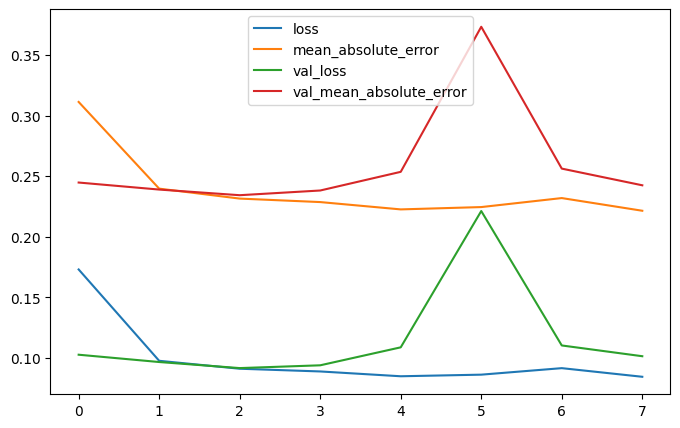

In [75]:
# Evaluate the model.
test_loss, test_metric_mae = lstm_model_baseline3.evaluate(test_ds, verbose=0)
print(f'Test MSE: {test_loss:.4f}')
print(f'Test MAE: {test_metric_mae:.4f}')


# Plot the training curves
pd.DataFrame(history_lstm_baseline.history).plot(figsize=(8,5))
plt.show()

In [76]:
print(num_test_targets) # number of test targets

6985


In [77]:
predict3 = lstm_model_baseline3.predict(test_ds) # predict is a list of predictions
num_pred_targets = len(predict3)
print(num_pred_targets) # number of test predictions

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
6985


In [78]:
lstm3_predict_temp = predict3[49]
actual_temp = temps_targets[49]
print(f'LSTM3 prediction temp : {lstm3_predict_temp[-1]}') # The last prediction (index 49) in a list of 24 predictions. 
print(f'Target temp: {actual_temp}')

LSTM3 prediction temp : [-1.1414431]
Target temp: -1.7721889440994996


In [79]:
# the first prediction at index 0 in the list of predictions of lstm3_predict_temp
print(f'LSTM3 prediction temp : {lstm3_predict_temp[0]}')

LSTM3 prediction temp : [-0.7752855]


Skapa en baseline även för detta fall. Notera att då vi predikterar precis 24h framåt så kommer denna baseline vara förvånads bra, fundera på vad som hade hänt ifall vi istället skulle prediktera 12h framåt istället för 24h.

Jämför sedan dina resultat i 2.1 och 2.2 med denna nya baseline.

### STUDENTSVAR (ANALYS):
Resultatet att prediktera temperaturen 24 timmar framåt blev inte jättebra. Temperaturdata varierar extremt mycket därför tror jag inte att det går att få fina resultat med LSTM. Dessutom så akumuleras fel från varje output i varje steg. Om vi skulle prediktera 12 h framåt skulle modellen ge bättre resultat då den inte akumulerar lika många fel från varje steg och temperaturerna är mera lika ju närmare input_width som dem är. MSE för Baseline modellen nedan var 0.25487870233413634 jämfört med MSE för LSTM Test MSE: 0.2405. De skiljdes sig med 0.01.

### STUDENTSVAR (KOD):

In [80]:
# Baseline calculation for predicting 24h into the future
# Min Baseline model for all temperature targets in test data
def baseline_temps_predictions(dfnorm,label_columns_index=lci):
    temps_targets = dfnorm['T (degC)'].to_numpy()
    temps_preds_list = []
    loss_sum = 0
    for label_columns_index in range(num_test_targets):
        if label_columns_index != 0:
            temp_baseline = temps_targets[label_columns_index-1]
            temps_preds_list.append(temp_baseline)
            loss = temps_targets[label_columns_index] - temp_baseline
            loss_sum += loss
        else:
            temp_baseline = temps_targets[label_columns_index]
            temps_preds_list.append(temp_baseline)
            loss = temp_baseline - temps_targets[label_columns_index]
            loss_sum += loss
    # mse = 1/n*(sum(preds-targets)^2)
    mse = (loss_sum * loss_sum)/num_test_targets
    return temps_preds_list, mse

In [81]:
temps_preds_list, mse_baseline = baseline_temps_predictions(dfnorm,label_columns_index=lci)
temp_pred_at_48h = temps_preds_list[49]
print(f'Predikterad temperatur med Baseline model: {temps_preds_list[49]}')  # Jämför predikterad temperatur med Baseline model och target
print(f'Riktiga temperaturen i test data set: {temps_targets[49]}')
print(f'Baseline Difference : {temps_preds_list[49] - temps_targets[49]} compared to LSTM3 Difference : {lstm3_predict_temp[-1] - actual_temp}' )

Predikterad temperatur med Baseline model: -1.6624251665125716
Riktiga temperaturen i test data set: -1.7721889440994996
Baseline Difference : 0.10976377758692801 compared to LSTM3 Difference : [0.63074577]


## Uppgift 24-timmar framåt med "mellanliggande prediktioner"
Del 2.2. Gör en prediktion av alla mellanliggande värden också. D.v.s använd återigen 24 timmars input-värden, men prediktera alla värden från timme 25 till och med timme 48. Din output blir nu en 24 värden lång vektor vid varje prediktion.

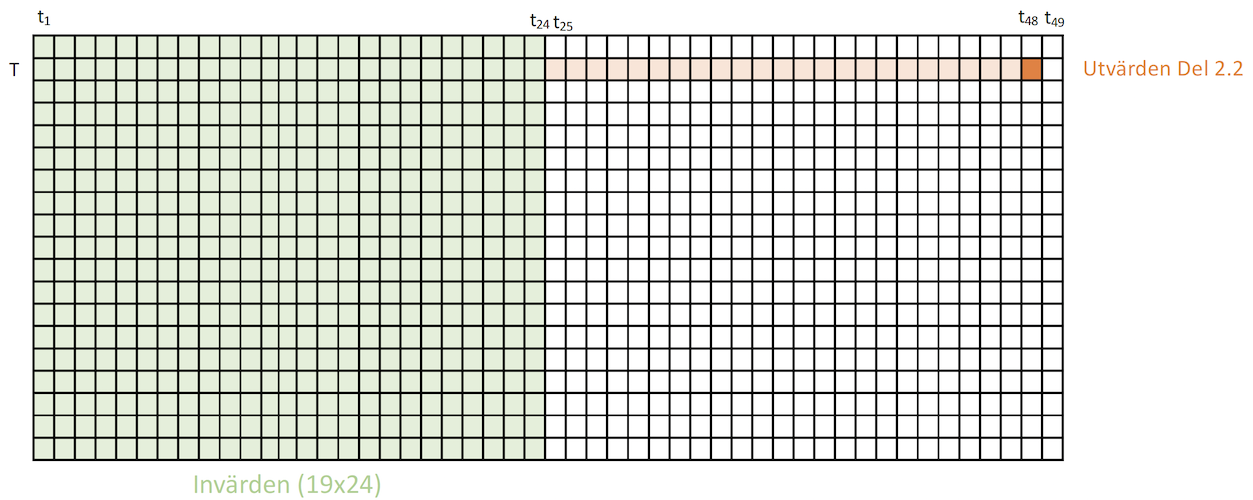

Notera att vi för dessa två modeller endast är intresserad av kvalitén av prediktionen vid timme 48, så du behöver hitta ett sätt att mäta prestationen för just denna timme för att kunna jämföra modellerna mot modell 2.1 och sinsemellan.

Du kan mäta felet på två sätt, antingen “manuellt” plocka ut målvärdena och prediktionen (sista värdet) för testdatat och och sedan beräkna felet enligt den metod du valt. Alternativt kan man skapa en “custom metric” (kapitel 12, s416), men du får eventuellt göra om från MSE till det mått du valt.

```
def last_time_step_mse(Y_true, Y_pred):
   return keras.losses.mean_squared_error(Y_true[:, -1], Y_pred[:, -1])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
```




### STUDENTSVAR (KOD):

In [82]:
# LSTM4 med shift 24 i stället för 1
# Define a windowing function that converts a dataframe into a TF dataset
# Had to jump to some hoops for this as keras.utils.timeseries_dataset_from_array do not support label_width>1
# https://github.com/keras-team/tf-keras/issues/7
def datasetgen(dataframe, input_width=24, label_width=1, shift=24, batch_size=128,
  label_columns=None, start_index=None, end_index=None, shuffle=False):
  """
  Generate timeseries dataset from the given dataframe containing a data sequence.

  Parameters:
  - dataframe: The source time sequence dataframe.
  - input_width: Number of time steps in each input sequence.
  - label_width: Number of time steps in each label sequence.
  - shift: How many steps to shift the end of the input to get the label.
  - batch_size: Size of batches to generate.
  - label_columns: List of column names to extract as labels. If None, all columns are used.
  - start_index: Start index from the dataframe to consider data. Default is the start of the dataframe.
  - end_index: End index from the dataframe to consider data. Default is the end of the dataframe.
  - shuffle: Whether to shuffle the generated batches. Note: shuffling won't work in the current implementation.

  Returns:
  - A TensorFlow Dataset containing input and label sequences.
  """

  # If end index or start index is not given, assign them to the end or start of the dataframe respectively.
  if end_index is None:
      end_index = len(dataframe) + input_width - 1
  if start_index is None:
      start_index = 0

  # Generate a input timeseries dataset from the dataframe using keras.utils.timeseries_dataset_from_array
  input_ds = keras.utils.timeseries_dataset_from_array(
                  dataframe, targets=None, sequence_length=input_width,
                  sequence_stride=1, sampling_rate=1, batch_size=batch_size, shuffle=shuffle,
                  start_index=start_index, end_index=(end_index-(input_width+shift)))

  # Fetch the indices of the label columns from the dataframe.
  label_columns_indices = get_label_columns_indices(dataframe,label_columns) # get the selected columns
  targetsdf = dataframe[list(label_columns_indices)] # Note that we only use names and not the indices

  # Generate a timeseries dataset of label sequences from the dataframe.
  # Here we assume that label_width should be less than or equal to shift.
  target_ds = keras.utils.timeseries_dataset_from_array(
                  targetsdf, targets=None, sequence_length=label_width,
                  sequence_stride=1, sampling_rate=1, batch_size=batch_size, shuffle=shuffle,
                  start_index=(start_index+(input_width+shift-label_width)),
                  end_index=end_index-input_width)

  # Combine input and target datasets to form a single dataset.
  train_ds = tf.data.Dataset.zip(input_ds,target_ds)

  return train_ds

In [83]:
# Now create the used datasets for part 1

input_width=24    # Input sequence length
shift=24           # How many steps to target
label_width=1     # Target sequence length
lcol=['T (degC)'] # Target parameter(s)
train_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=0, end_index=split1ix)
val_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=split1ix, end_index=split2ix)  # Is this correct? WE are using the dfnorm based on the training data instead of the dfnorm_validation ??
test_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=split2ix, end_index=None)

In [84]:
# Establish test targets (to show how to unroll dataset)
test_targets = None
for batch in test_ds:
  inputs, targets = batch
  if test_targets == None:
    test_targets = targets
  else:
   test_targets = tf.concat([test_targets,targets], axis=0)

# Print number of targets (i.e. windows in target dataset)
num_test_targets = test_targets.shape[0]
print(f'No of targets = {num_test_targets}')
# And number of features
num_target_features = targets.shape[-1]
print(f'No of features in target = {num_target_features}')

No of targets = 6962
No of features in target = 1


In [85]:
# Get a batch and look at the shapes for one of the datasets
eval_ds = test_ds
for batch in eval_ds:
  inputs, targets = batch
  batchlen = len(inputs)
  # We here have a batch of seqlen sequences
  print("A Batch Input shape = {0}, Output shape = {1}".format(inputs.shape,targets.shape))
  break

print(f'No batches = {eval_ds.__len__()}')

A Batch Input shape = (128, 24, 19), Output shape = (128, 1, 1)
No batches = 55


In [86]:
# A good LSTM model from above but predict at 48 instead of 1

lstm_model_baseline4 = keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    keras.layers.LSTM(256, return_sequences=True), # Tried return_sequences False, True and LSTM(32, 128, 256)
    #keras.layers.LSTM(256, return_sequences=True),
    # Shape => [batch, time, features]
    keras.layers.Dense(units=num_target_features)
])

In [87]:
MAX_EPOCHS = 30

def compile_and_fit(model, patience=5):
  early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min',
                                                    restore_best_weights = True)

  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=tf.optimizers.Adam(),
                metrics=[tf.metrics.MeanAbsoluteError()])

  start = time.time()
  history = model.fit(train_ds, epochs=MAX_EPOCHS,
                      validation_data=val_ds,
                      callbacks=[early_stopping])
  end = time.time()
  print(f'Time to run: {end - start:.1f}s')

  return history,model

In [88]:
# Compile and train this model
history_lstm_baseline,lstm_model_baseline4=compile_and_fit(lstm_model_baseline4)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3486 - mean_absolute_error: 0.4452 - val_loss: 0.1890 - val_mean_absolute_error: 0.3457
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2112 - mean_absolute_error: 0.3518 - val_loss: 0.1888 - val_mean_absolute_error: 0.3481
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2038 - mean_absolute_error: 0.3451 - val_loss: 0.1637 - val_mean_absolute_error: 0.3218
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1921 - mean_absolute_error: 0.3350 - val_loss: 0.2268 - val_mean_absolute_error: 0.3848
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2085 - mean_absolute_error: 0.3470 - val_loss: 0.1961 - val_mean_absolute_error: 0.3589
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1960 - mean_absolute_error: 0.3350 - val_loss: 0.2133 - val_mean_absolute_error: 0.3750
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1943 - mean_absolute_error: 0.3

Test MSE: 0.1478
Test MAE: 0.3061


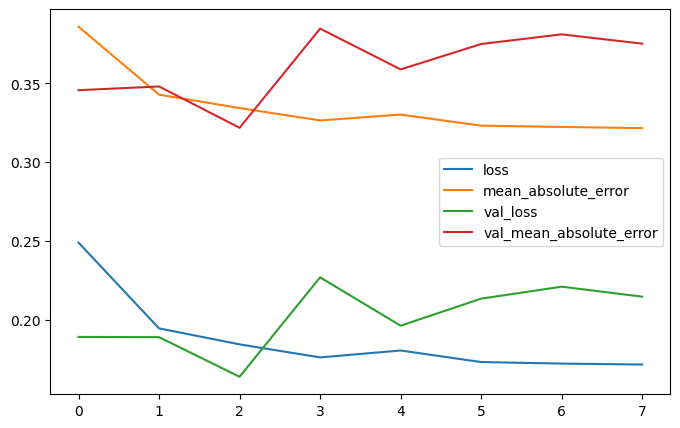

In [89]:
# Evaluate the model.
test_loss, test_metric_mae = lstm_model_baseline4.evaluate(test_ds, verbose=0)
print(f'Test MSE: {test_loss:.4f}')
print(f'Test MAE: {test_metric_mae:.4f}')


# Plot the training curves
pd.DataFrame(history_lstm_baseline.history).plot(figsize=(8,5))
plt.show()

In [90]:
print(num_test_targets) # number of test targets

6962


In [114]:
predict4 = lstm_model_baseline4.predict(test_ds) # predict is a list of predictions
num_pred_targets = len(predict4)
print(num_pred_targets) # number of test predictions
print(predict4.shape)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
6985
(6985, 24, 1)


In [115]:
lstm4_predict_temp = predict4[49]
actual_temp = temps_targets[49]
print(f'LSTM4 prediction temp : {lstm4_predict_temp[23]}') # The last prediction (index 49) in a list of 24 predictions. 
print(f'Target temp: {actual_temp}')
print(lstm4_predict_temp[0])
print(lstm4_predict_temp)
print(lstm4_predict_temp.shape)
print(actual_temp.shape)

LSTM4 prediction temp : [-0.37362728]
Target temp: -1.7721889440994996
[-0.4999003]
[[-0.4999003 ]
 [-0.5272523 ]
 [-0.32982352]
 [-0.36864254]
 [-0.37541974]
 [-0.42573863]
 [-0.4066638 ]
 [-0.47761646]
 [-0.43793857]
 [-0.28123435]
 [-0.36881328]
 [-0.35515103]
 [-0.28233677]
 [-0.40059212]
 [-0.35097125]
 [-0.3453358 ]
 [-0.37507847]
 [-0.32408294]
 [-0.35159937]
 [-0.3029373 ]
 [-0.32901517]
 [-0.34621188]
 [-0.40195408]
 [-0.37362728]]
(24, 1)
()


In [93]:
def temps_predictions_mse(preds_list, dfnorm, test_pred_nums=49,label_columns_index=lci):
    temps_targets = dfnorm['T (degC)'].to_numpy()
    loss_sum = 0
    for label_columns_index in range(24):
        if label_columns_index != 0:
            pred = preds_list[label_columns_index-1]
            loss = pred - temps_targets[label_columns_index]
            loss_sum += loss
        else:
            pred = preds_list[label_columns_index]
            loss = pred - temps_targets[label_columns_index]
            loss_sum += loss
    # mse = 1/n*(sum(preds-targets)^2)
    mse = (loss_sum * loss_sum)/num_test_targets
    return mse

In [94]:
lstm4_mse = temps_predictions_mse(lstm4_predict_temp, dfnorm, num_test_targets, label_columns_index=lci)
print(lstm4_mse)

[0.17428394]


In [95]:
lstm3_mse = temps_predictions_mse(lstm3_predict_temp, dfnorm, num_test_targets, label_columns_index=lci)
print(lstm3_mse)

[0.06157541]


In [96]:
baseline_mse = mse_baseline
print(baseline_mse)

0.00020870701664831153


In [97]:
print(f'Baseline MSE : {baseline_mse} compared to LSTM3 Difference : {lstm3_mse} and \n compared to LSTM4 Difference: {lstm4_mse}' )

Baseline MSE : 0.00020870701664831153 compared to LSTM3 Difference : [0.06157541] and 
 compared to LSTM4 Difference: [0.17428394]


## Uppgift -- Analys
Jämför prestandan för dina olika modeller sinsemellan och mot baseline, vilka slutsatser drar du? Och, hur väl presterar dessa modeller i jämförelse med fallet i del 1 där vi bara behövde prediktera ett steg framåt?

### STUDENTSVAR (ANALYS):
Baseline Modellen var bäst på att prediktera temperatur med en mse av 0.00025007, medans LSTM3 har mse = 0.09971775 or LSTM4 har mse = 0.16499. LSTM1 som predikterade temperatur ett steg framåt och med mse  = 0.0072 gav okej resultat men slog inte baseline modellen. LSTM1 var ändå bättre än LSTM3 och LSTM4 som båda predikterade temperatur 24 timmar framåt i tiden på olika vis.


# VG Del

##Uppgift - GRU
Pröva att ersätta LSTM med GRU (en annan RNN modell) med samma antal noder och lager som för din bästa LSTM modell i del 1. Finner du någon skillnad i prestanda, konvergens, tidsåtgång vid träning, eller annat?

### ********************STUDENTSVAR VG (KOD):

In [98]:
# Define a windowing function that converts a dataframe into a TF dataset
# Had to jump to some hoops for this as keras.utils.timeseries_dataset_from_array do not support label_width>1
# https://github.com/keras-team/tf-keras/issues/7
def datasetgen(dataframe, input_width=24, label_width=1, shift=1, batch_size=128,
  label_columns=None, start_index=None, end_index=None, shuffle=False):
  """
  Generate timeseries dataset from the given dataframe containing a data sequence.

  Parameters:
  - dataframe: The source time sequence dataframe.
  - input_width: Number of time steps in each input sequence.
  - label_width: Number of time steps in each label sequence.
  - shift: How many steps to shift the end of the input to get the label.
  - batch_size: Size of batches to generate.
  - label_columns: List of column names to extract as labels. If None, all columns are used.
  - start_index: Start index from the dataframe to consider data. Default is the start of the dataframe.
  - end_index: End index from the dataframe to consider data. Default is the end of the dataframe.
  - shuffle: Whether to shuffle the generated batches. Note: shuffling won't work in the current implementation.

  Returns:
  - A TensorFlow Dataset containing input and label sequences.
  """

  # If end index or start index is not given, assign them to the end or start of the dataframe respectively.
  if end_index is None:
      end_index = len(dataframe) + input_width - 1
  if start_index is None:
      start_index = 0

  # Generate a input timeseries dataset from the dataframe using keras.utils.timeseries_dataset_from_array
  input_ds = keras.utils.timeseries_dataset_from_array(
                  dataframe, targets=None, sequence_length=input_width,
                  sequence_stride=1, sampling_rate=1, batch_size=batch_size, shuffle=shuffle,
                  start_index=start_index, end_index=(end_index-(input_width+shift)))

  # Fetch the indices of the label columns from the dataframe.
  label_columns_indices = get_label_columns_indices(dataframe,label_columns) # get the selected columns
  targetsdf = dataframe[list(label_columns_indices)] # Note that we only use names and not the indices

  # Generate a timeseries dataset of label sequences from the dataframe.
  # Here we assume that label_width should be less than or equal to shift.
  target_ds = keras.utils.timeseries_dataset_from_array(
                  targetsdf, targets=None, sequence_length=label_width,
                  sequence_stride=1, sampling_rate=1, batch_size=batch_size, shuffle=shuffle,
                  start_index=(start_index+(input_width+shift-label_width)),
                  end_index=end_index-input_width)

  # Combine input and target datasets to form a single dataset.
  train_ds = tf.data.Dataset.zip(input_ds,target_ds)

  return train_ds

In [99]:
# Now create the used datasets for part 1

input_width=24    # Input sequence length
shift=1           # How many steps to target
label_width=1     # Target sequence length
lcol=['T (degC)'] # Target parameter(s)
train_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=0, end_index=split1ix)
val_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=split1ix, end_index=split2ix)  # Is this correct? WE are using the dfnorm based on the training data instead of the dfnorm_validation ??
test_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=split2ix, end_index=None)

In [100]:
# Establish test targets (to show how to unroll dataset)
test_targets = None
for batch in test_ds:
  inputs, targets = batch
  if test_targets == None:
    test_targets = targets
  else:
   test_targets = tf.concat([test_targets,targets], axis=0)

# Print number of targets (i.e. windows in target dataset)
num_test_targets = test_targets.shape[0]
print(f'No of targets = {num_test_targets}')
# And number of features
num_target_features = targets.shape[-1]
print(f'No of features in target = {num_target_features}')

No of targets = 6985
No of features in target = 1


In [101]:
# Get a batch and look at the shapes for one of the datasets
eval_ds = test_ds
for batch in eval_ds:
  inputs, targets = batch
  batchlen = len(inputs)
  # We here have a batch of seqlen sequences
  print("A Batch Input shape = {0}, Output shape = {1}".format(inputs.shape,targets.shape))
  break

print(f'No batches = {eval_ds.__len__()}')

A Batch Input shape = (128, 24, 19), Output shape = (128, 1, 1)
No batches = 55


In [102]:
MAX_EPOCHS = 30

def compile_and_fit(model, patience=5):
  early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min',
                                                    restore_best_weights = True)

  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=tf.optimizers.Adam(),
                metrics=[tf.metrics.MeanAbsoluteError()])

  start = time.time()
  history = model.fit(train_ds, epochs=MAX_EPOCHS,
                      validation_data=val_ds,
                      callbacks=[early_stopping])
  end = time.time()
  print(f'Time to run: {end - start:.1f}s')

  return history,model

In [103]:
# An GRU model: definition, compile and run, evaluate, and compare!

from keras.optimizers import RMSprop

model_gru = keras.models.Sequential()
#model_gru.add(layers.Conv1D(filters=32, kernel_size=4, strides=2, activation="relu"))
model_gru.add(layers.GRU(32, return_sequences=True))
model_gru.add(layers.GRU(32, return_sequences=True))
model_gru.add(layers.Dense(1))

In [104]:
# Compile and train this model
history_gru_baseline,model_gru = compile_and_fit(model_gru)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.4127 - mean_absolute_error: 0.4635 - val_loss: 0.1552 - val_mean_absolute_error: 0.3078
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1479 - mean_absolute_error: 0.2987 - val_loss: 0.1558 - val_mean_absolute_error: 0.3179
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1223 - mean_absolute_error: 0.2688 - val_loss: 0.1267 - val_mean_absolute_error: 0.2808
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1148 - mean_absolute_error: 0.2624 - val_loss: 0.0908 - val_mean_absolute_error: 0.2336
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0935 - mean_absolute_error: 0.2338 - val_loss: 0.0844 - val_mean_absolute_error: 0.2230
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0885 - mean_absolute_error: 0.2268 - val_loss: 0.0884 - val_mean_absolute_error: 0.2294
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0875 - mean_absolute_error: 0.2

Test MSE: 0.0713
Test MAE: 0.2073


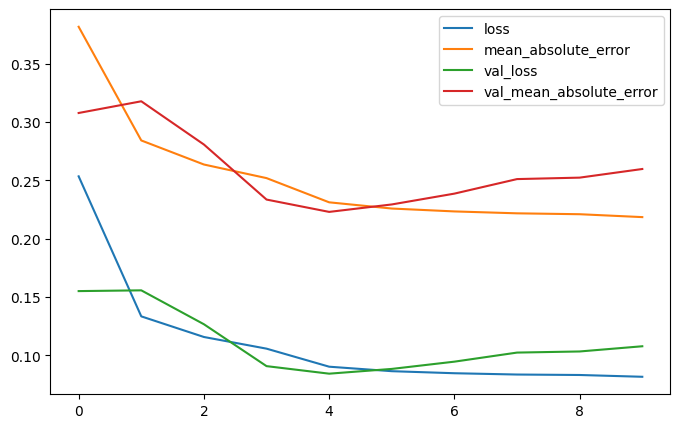

In [105]:
# Evaluate the model.
test_loss, test_metric_mae = model_gru.evaluate(test_ds, verbose=0)
print(f'Test MSE: {test_loss:.4f}')
print(f'Test MAE: {test_metric_mae:.4f}')


# Plot the training curves
pd.DataFrame(history_gru_baseline.history).plot(figsize=(8,5))
plt.show()

In [109]:
predict_gru = model_gru.predict(test_ds)
print(predict_gru[0, 0, 0]) # along column 0 row 0
print(predict_gru[0]) # along the row for all columns
predict_gru.shape

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
-0.73814905
[[-0.73814905]
 [-0.6675041 ]
 [-0.6900612 ]
 [-0.6350811 ]
 [-0.66790646]
 [-0.60727066]
 [-0.6228724 ]
 [-0.5968819 ]
 [-0.59934336]
 [-0.5677194 ]
 [-0.57439923]
 [-0.5883722 ]
 [-0.57836723]
 [-0.598256  ]
 [-0.6933505 ]
 [-0.7865843 ]
 [-0.8854419 ]
 [-0.9195065 ]
 [-0.9923648 ]
 [-1.0272758 ]
 [-1.0271654 ]
 [-1.013963  ]
 [-1.0266957 ]
 [-1.0403951 ]]


(6985, 24, 1)

### STUDENTSVAR VG (ANALYS): 
Gru modellen kör fortare - 53.8s jämfört med LSTM1 115.3 s men jag ser inte en förbättring i prestandan Test MSE: 0.0713
Test MAE: 0.2073 jämfört med LSTM1 Test MSE: 0.0067 Test MAE: 0.0613 

## Uppgift - "Breda prediktioner" 24-timmar framåt
Du ska som i Del 2 prediktera vad temperaturen är vid timme 48. Men denna gång ska du göra en prediktion av alla 19 parametrar vid timme 48 och använda summafelet av alla dessa parametrar för träningen. Du ska dock utvärdera modellen bara utifrån hur den predikterar temperaturen vid timme 48. Detta så att du kan jämföra med de resultat du fått i 2.1 och 2.2.

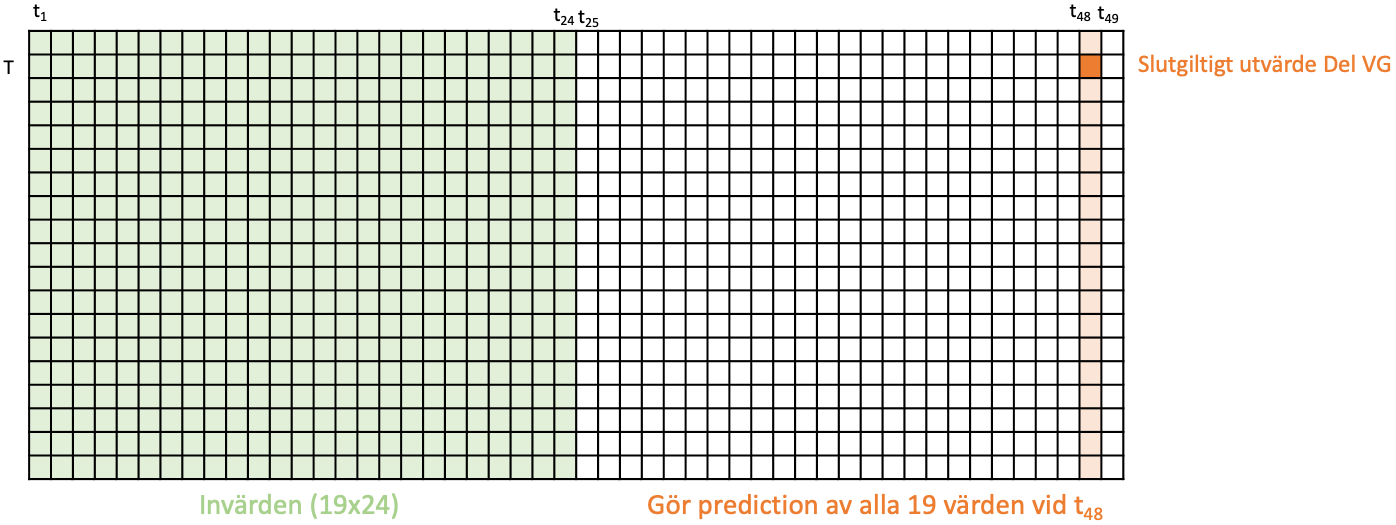

### STUDENTSVAR VG (KOD):

In [116]:
# Kod för "Breda prediktioner" 24-timmar framåt
# Now create the used datasets for part 1

input_width=24    # Input sequence length
shift=1           # How many steps to target
label_width=24     # Target sequence length
lcol= None # All Target parameter(s)
train_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=0, end_index=split1ix)
val_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=split1ix, end_index=split2ix)  # Is this correct? WE are using the dfnorm based on the training data instead of the dfnorm_validation ??
test_ds = datasetgen(dfnorm, input_width=input_width, label_width=label_width, shift=shift,
              label_columns=lcol, start_index=split2ix, end_index=None)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [117]:
# Establish test targets (to show how to unroll dataset)
test_targets = None
for batch in test_ds:
  inputs, targets = batch
  if test_targets == None:
    test_targets = targets
  else:
   test_targets = tf.concat([test_targets,targets], axis=0)

# Print number of targets (i.e. windows in target dataset)
num_test_targets = test_targets.shape[0]
print(f'No of targets = {num_test_targets}')
# And number of features
num_target_features = targets.shape[-1]
print(f'No of features in target = {num_target_features}')

No of targets = 6985
No of features in target = 19


In [118]:
# Get a batch and look at the shapes for one of the datasets
eval_ds = test_ds
for batch in eval_ds:
  inputs, targets = batch
  batchlen = len(inputs)
  # We here have a batch of seqlen sequences
  print("A Batch Input shape = {0}, Output shape = {1}".format(inputs.shape,targets.shape))
  break

print(f'No batches = {eval_ds.__len__()}')

A Batch Input shape = (128, 24, 19), Output shape = (128, 24, 19)
No batches = 55


In [119]:
MAX_EPOCHS = 30

def compile_and_fit(model, patience=5):
  early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min',
                                                    restore_best_weights = True)

  model.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=tf.optimizers.Adam(),
                metrics=[tf.metrics.MeanAbsoluteError()])

  start = time.time()
  history = model.fit(train_ds, epochs=MAX_EPOCHS,
                      validation_data=val_ds,
                      callbacks=[early_stopping])
  end = time.time()
  print(f'Time to run: {end - start:.1f}s')

  return history,model

In [125]:
# An GRU model: definition, compile and run, evaluate, and compare!

from keras.optimizers import RMSprop

model_gru = keras.models.Sequential()
#model_gru.add(layers.Conv1D(filters=32, kernel_size=4, strides=2, activation="relu"))
model_gru.add(layers.GRU(32, return_sequences=True))
model_gru.add(layers.GRU(32, return_sequences=True))
model_gru.add(layers.Dense(1))

In [126]:
# Compile and train this model
history_gru_baseline,model_gru = compile_and_fit(model_gru)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.9607 - mean_absolute_error: 0.7825 - val_loss: 0.8999 - val_mean_absolute_error: 0.7680
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.9269 - mean_absolute_error: 0.7719 - val_loss: 0.8474 - val_mean_absolute_error: 0.7349
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.9157 - mean_absolute_error: 0.7681 - val_loss: 0.8520 - val_mean_absolute_error: 0.7404
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.9163 - mean_absolute_error: 0.7682 - val_loss: 0.8576 - val_mean_absolute_error: 0.7419
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.9178 - mean_absolute_error: 0.7685 - val_loss: 0.8521 - val_mean_absolute_error: 0.7351
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.9168 - mean_absolute_error: 0.7683 - val_loss: 0.8493 - val_mean_absolute_error: 0.7313
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.9160 - mean_absolute_error: 0.7

Test MSE: 0.8907
Test MAE: 0.7518


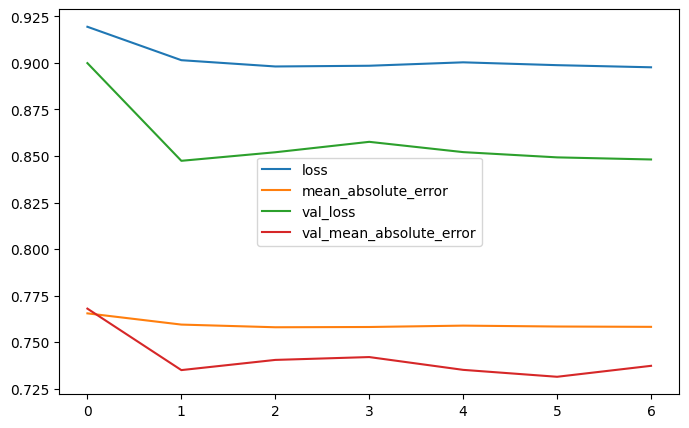

In [127]:
# Evaluate the model.
test_loss, test_metric_mae = model_gru.evaluate(test_ds, verbose=0)
print(f'Test MSE: {test_loss:.4f}')
print(f'Test MAE: {test_metric_mae:.4f}')


# Plot the training curves
pd.DataFrame(history_gru_baseline.history).plot(figsize=(8,5))
plt.show()

In [139]:
predict_gru = model_gru.predict(test_ds)
print(predict_gru[0:23, 19:23]) # along column 0 row 0
#print(predict_gru[1,23]) # along the row for all columns
predict_gru.shape

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
[[[0.21487789]
  [0.21810253]
  [0.17604488]
  [0.16450687]]

 [[0.21842629]
  [0.1763638 ]
  [0.16482155]
  [0.14089869]]

 [[0.1767597 ]
  [0.16521722]
  [0.1412979 ]
  [0.1735719 ]]

 [[0.1657338 ]
  [0.14181356]
  [0.17401679]
  [0.19959323]]

 [[0.14223507]
  [0.17438339]
  [0.19988663]
  [0.23451723]]

 [[0.17473944]
  [0.20016028]
  [0.23470756]
  [0.27363664]]

 [[0.2003705 ]
  [0.2348472 ]
  [0.273723  ]
  [0.28095165]]

 [[0.23489283]
  [0.27373323]
  [0.2809448 ]
  [0.2417951 ]]

 [[0.27370363]
  [0.28089577]
  [0.24174727]
  [0.26418465]]

 [[0.28081456]
  [0.24166931]
  [0.2640915 ]
  [0.23576853]]

 [[0.24146327]
  [0.2639005 ]
  [0.23561594]
  [0.2679301 ]]

 [[0.2636674 ]
  [0.23542516]
  [0.26775306]
  [0.3261074 ]]

 [[0.23520094]
  [0.26755115]
  [0.325912  ]
  [0.34583175]]

 [[0.26734003]
  [0.3256991 ]
  [0.3456449 ]
  [0.28524047]]

 [[0.3254378 ]
  [0.34541655]
  [0.28506127]
  [0.25656733]]

 [[0.34517276]
  [0.28487086]
 

(6985, 24, 1)

## Uppgift -- Analys
Jämför prestandan för dina olika modeller sinsemellan, vilka slutsatser drar du? Och, hur väl presterar denna modell i jämförelse med de du analyserade i del 2?

### STUDENTSVAR VG (ANALYS): Generellt sätt så är jag inte jätteimponerad av GRU för att den verkar prestera sämre än LSTM. Antingen det eller så använder jag den fel. 

#Referenser
Delar av denna kod är baserat på
* Tidigare TF-exempel https://www.tensorflow.org/tutorials/structured_data/time_series
* Läroboken Kapitel 15, från "Preparing the Data for Machine Learning Models", s. 552, och dess kodexempel: https://github.com/ageron/handson-ml3/blob/main/15_processing_sequences_using_rnns_and_cnns.ipynb
* Timeseries forecasting for weather prediction https://keras.io/examples/timeseries/timeseries_weather_forecasting/ (but note that this code is not doing a correct preprocessing/feature engineering of various features like: missing values in wind speed, wind direction, and time.)

# AI Deklaration
Användning av Al-verktyg är "tillåtet", men vi vill se kommentar i koden, där det har använts för att skapa hela block av kod.

Här på slutet ska du ange allmänt vilka AI-verktyg som använts, hur du använt dem, och hur användbara dessa verktyg är. Om du inte använt AI-stöd så skriv bara att "AI-verktyg har ej använts".

### STUDENTSVAR (AI-användning): Jag har inte använt AI för att generera kod förutom mse-formlern. Istället har jag hållit mig till läroboken, och Francois Chollet men tyckte att det blev mycket förvirrande med begreppen step, shift, input_width etc jämfört med look_back, delay osv. 